In [2]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('transact_18_22.csv')

data = data[data['value'].isin(['survival', 'self_realization', 'socialization'])]

data = data.drop(columns=['mcc', 'group', 'value', 'card'], errors='ignore')



data = data.groupby(['date', 'client'], as_index=False).agg({
        'amt': 'sum'
})

data['date'] = pd.to_datetime(data['date'], errors='coerce')
data = data.set_index('date')
data.head()

,client,amt
date,,
2018-01-01,3845,1775.00
2018-01-01,5044,13259.00
2018-01-01,6908,350.00
2018-01-01,8332,246.39
2018-01-01,12014,199.00


In [3]:
def get_client_df(client_id):

    client_df = data[data['client'] == client_id].copy()

    client_df = client_df.drop(columns=['client'], errors='ignore')

    start_date = client_df.index.min()

    end_date = pd.Timestamp('2020-03-15')

#     end_date = client_df.index.max()

    full_range = pd.date_range(
        start=start_date,
        end=end_date,
        freq='D'
    )

    client_df = client_df.reindex(full_range)
    client_df['amt'] = client_df['amt'].fillna(0)
    client_df['date'] = client_df.index.values
    client_df = client_df.reset_index()
    client_df = client_df.drop(columns=['index'], errors='ignore')
    return client_df


In [4]:
data.head()

,client,amt
date,,
2018-01-01,3845,1775.00
2018-01-01,5044,13259.00
2018-01-01,6908,350.00
2018-01-01,8332,246.39
2018-01-01,12014,199.00


In [30]:
import numpy as np
from holidays import CountryHoliday


def create_features_old(df):
    
    for lag in [1, 2, 3, 7, 14, 30]:
        df[f'lag_{lag}'] = df['amt'].shift(lag)
        
    
    df['rolling_7d_mean'] = df['amt'].rolling(7).mean().shift(1)
    df['rolling_7d_sum'] = df['amt'].rolling(7).sum().shift(1)
    df['rolling_30d_mean'] = df['amt'].rolling(30).mean().shift(1)  # New
    df['rolling_30d_sum'] = df['amt'].rolling(30).sum().shift(1)    # New
    
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_month'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    
    df['is_weekend'] = df['date'].dt.weekday >= 5
    
    days_in_month = df['date'].dt.days_in_month
    
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    
    df['day_of_month_sin'] = np.sin(2 * np.pi * (df['day_of_month'] - 1) / days_in_month)
    df['day_of_month_cos'] = np.cos(2 * np.pi * (df['day_of_month'] - 1) / days_in_month)
    
    is_first_half = df['day_of_month'] <= (days_in_month // 2)
    semi_month_period = np.where(
        is_first_half,
        days_in_month // 2,
        days_in_month - (days_in_month // 2)
    )
    semi_month_day = np.where(
        is_first_half,
        df['day_of_month'] - 1,
        df['day_of_month'] - 1 - (days_in_month // 2)
    )
    
    df['semi_month_sin'] = np.sin(2 * np.pi * semi_month_day / semi_month_period)
    df['semi_month_cos'] = np.cos(2 * np.pi * semi_month_day / semi_month_period)
    
    df['month_sin'] = np.sin(2 * np.pi * (df['month'] - 1) / 12)
    df['month_cos'] = np.cos(2 * np.pi * (df['month'] - 1) / 12)
    
    df['month_cumsum'] = df.groupby([df['date'].dt.year, df['date'].dt.month])['amt'].cumsum()
    df['week_cumsum'] = df.groupby([df['date'].dt.isocalendar().year, df['date'].dt.isocalendar().week])['amt'].cumsum()          
    
    df['target'] = df['amt']
    
    return df.drop(columns=['day_of_month', 'amt', 'date', 'month']).dropna()


def create_features(df):
    for lag in [1, 2, 3, 4, 5, 6, 7, 14, 30]:
        df[f'lag_{lag}'] = df['amt'].shift(lag)
    
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_month'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    
    df['is_weekend'] = (df['date'].dt.weekday >= 5).astype(int)
    
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_month_sin'] = np.sin(2 * np.pi * (df['day_of_month'] - 1) / 31)
    df['day_of_month_cos'] = np.cos(2 * np.pi * (df['day_of_month'] - 1) / 31)
    
    df['target'] = df['amt']
    
    
    return df.drop(columns=[
        'day_of_week',
        'day_of_month', 'amt', 'date']).dropna()



In [20]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import matplotlib.pyplot as plt  # Added import for plotting
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit

def evaluate_model(client_df, model_constructor, params, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=7)
    scores = []
    
    print("Temporal Cross-Validation Results:")
    for fold, (train_idx, test_idx) in enumerate(tscv.split(client_df)):
        raw_train = client_df.iloc[train_idx].copy()
        raw_test = client_df.iloc[test_idx].copy()
        
        train_featured = create_features(raw_train)
        
        train_featured_indices = train_featured.index
        train_dates = raw_train.loc[train_featured_indices, 'date']
        
        split_idx = int(0.8 * len(train_featured))
        X_train = train_featured.iloc[:split_idx].drop(columns=['target'])
        y_train = train_featured.iloc[:split_idx]['target']
        X_val = train_featured.iloc[split_idx:].drop(columns=['target'])
        y_val = train_featured.iloc[split_idx:]['target']
        
        buffer_dates = train_dates.iloc[:split_idx].tolist()
        buffer_amts = y_train.tolist()
        
        model = model_constructor(**params)
        
        
        
        if isinstance(model, HistoricalMeanBaseline):
            model.fit(
                X_train, y_train
            )
            print(model.day_means)
            print(model.overall_mean)
        else:
            
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                verbose=False
            )
        
        buffer = y_train.tolist()
        y_pred = []
        y_test = raw_test['amt'].tolist()
        
        for i in range(len(raw_test)):
            current_date = raw_test.iloc[i]['date']
            current_day = current_date.day
            current_month = current_date.month
            days_in_month = current_date.days_in_month
            
            is_first_half = current_day <= (days_in_month // 2)
            if is_first_half:
                semi_month_period = days_in_month // 2
                semi_month_day = current_day - 1
            else:
                semi_month_period = days_in_month - (days_in_month // 2)
                semi_month_day = current_day - 1 - (days_in_month // 2)
            
            month_cumsum = sum(
                amt for date, amt in zip(buffer_dates, buffer_amts)
                if date.month == current_month and date.year == current_date.year
            )
            week_cumsum = sum(
                amt for date, amt in zip(buffer_dates, buffer_amts)
                if date.isocalendar().year == current_date.isocalendar().year
                and date.isocalendar().week == current_date.isocalendar().week
            )
            
            rolling_7d_mean = np.mean(buffer_amts[-7:]) if len(buffer_amts) >= 7 else 0
            rolling_7d_sum = np.sum(buffer_amts[-7:]) if len(buffer_amts) >= 7 else 0
            rolling_30d_mean = np.mean(buffer_amts[-30:]) if len(buffer_amts) >= 30 else 0
            rolling_30d_sum = np.sum(buffer_amts[-30:]) if len(buffer_amts) >= 30 else 0
            
            features = {
                **{f'lag_{lag}': buffer[-lag] if len(buffer)>=lag else 0 
                   for lag in [1, 2, 3, 4, 5, 6, 7, 14, 30]},
                'month': current_month,
        
                'is_weekend': current_date.weekday() >= 5,
            
                'day_of_week_sin': np.sin(2 * np.pi * current_date.dayofweek / 7),
                'day_of_week_cos': np.cos(2 * np.pi * current_date.dayofweek / 7),
                'day_of_month_sin': np.sin(2 * np.pi * (current_day - 1) / days_in_month),
                'day_of_month_cos': np.cos(2 * np.pi * (current_day - 1) / days_in_month)
            }
                
            
            X_test_i = pd.DataFrame([features])
            pred = model.predict(X_test_i)[0]
            y_pred.append(pred)
            buffer.append(pred)
        
        mae = mean_absolute_error(y_test, y_pred)
        mean_real_value = np.mean(y_test)
        mae_ratio = mae / mean_real_value if mean_real_value != 0 else np.nan
        
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        
        scores.append({
            'fold': fold + 1,
            'train_start': raw_train['date'].iloc[0].date(),
            'train_end': raw_train['date'].iloc[-1].date(),
            'test_start': raw_test['date'].iloc[0].date(),
            'test_end': raw_test['date'].iloc[-1].date(),
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2,
            'mae_ratio': mae_ratio
        })
        
        plt.figure(figsize=(10, 6))
        plt.plot(
            raw_test['date'],
            y_test,
            label='Actual', 
            marker='o'
        )
        plt.plot(
            raw_test['date'],
            y_pred,
            label='Predicted', 
            marker='x', 
            linestyle='--'
        )
        plt.xlabel('Date')
        plt.ylabel('Target Value')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
        print(f"\nFold {fold+1} ({len(train_idx)} train / {len(test_idx)} test)")
        print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")

    results_df = pd.DataFrame(scores)
    avg_metrics = {
        'avg_MAE': results_df['MAE'].mean(),
        'avg_MSE': results_df['MSE'].mean(),
        'avg_RMSE': results_df['RMSE'].mean(),
        'avg_R2': results_df['R2'].mean(),
        'avg_mae_ratio': results_df['mae_ratio'].mean()
    }
    
    print("\nAverage Metrics Across Folds:")
    print(f"MAE: {avg_metrics['avg_MAE']:.3f}")
    print(f"RMSE: {avg_metrics['avg_RMSE']:.3f}")
    print(f"R2: {avg_metrics['avg_R2']:.3f}")
    print(f"mae_ratio: {avg_metrics['avg_mae_ratio']:.3f}")
    
    return results_df, avg_metrics

In [10]:
def evaluate_model_on_clients(data, clients, model_constructor, params):
    metrics = {}
    for client_id in clients:
        client_df = get_client_df(client_id)
        _, client_metrics = evaluate_model(client_df, model_constructor, params)
        metrics[client_id] = client_metrics
    return metrics

In [45]:
import xgboost as xgb
model = xgb.XGBRegressor
params = {
    "objective": 'reg:squarederror',
    "n_estimators": 3000,
    "learning_rate": 0.1,
    "max_depth": 5, 
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "early_stopping_rounds": 2000
}

In [63]:
client_df = get_client_df(1926324)
client_df

,amt,date
0,437.99,2022-03-21


Temporal Cross-Validation Results:


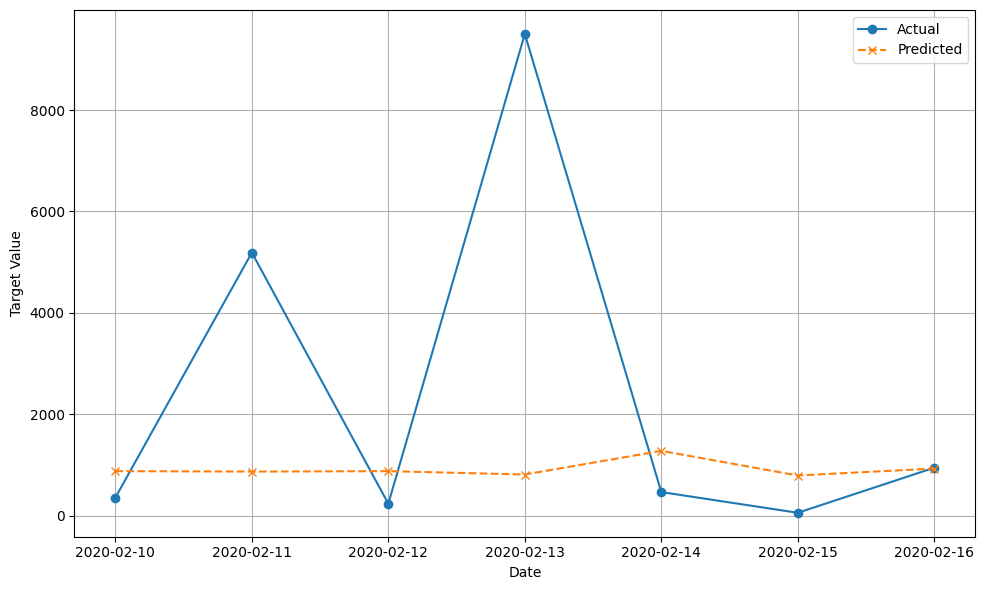


Fold 1 (757 train / 7 test)
MAE: 2248.824, RMSE: 3705.208, R2: -0.225


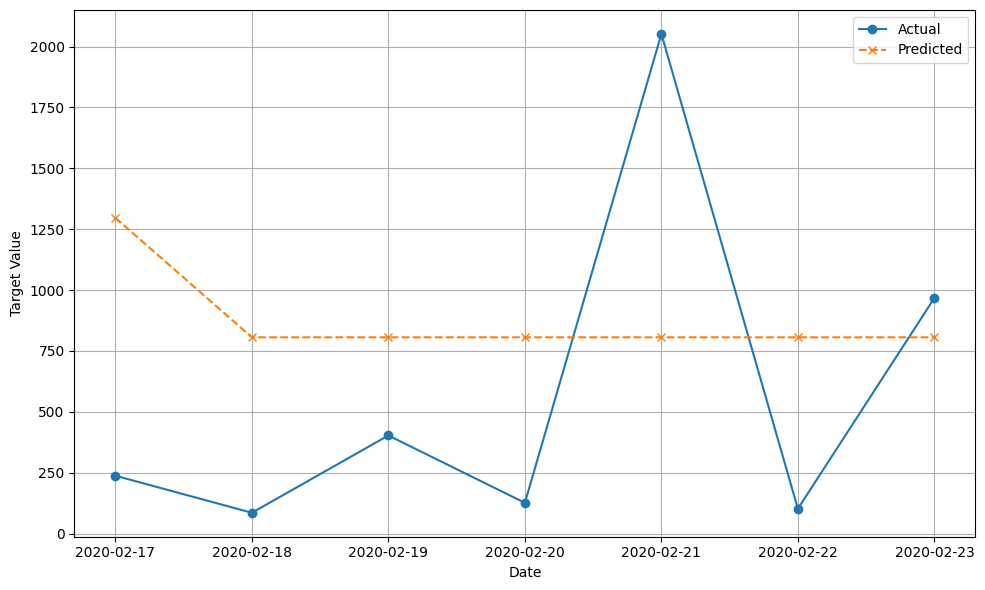


Fold 2 (764 train / 7 test)
MAE: 710.588, RMSE: 787.360, R2: -0.381


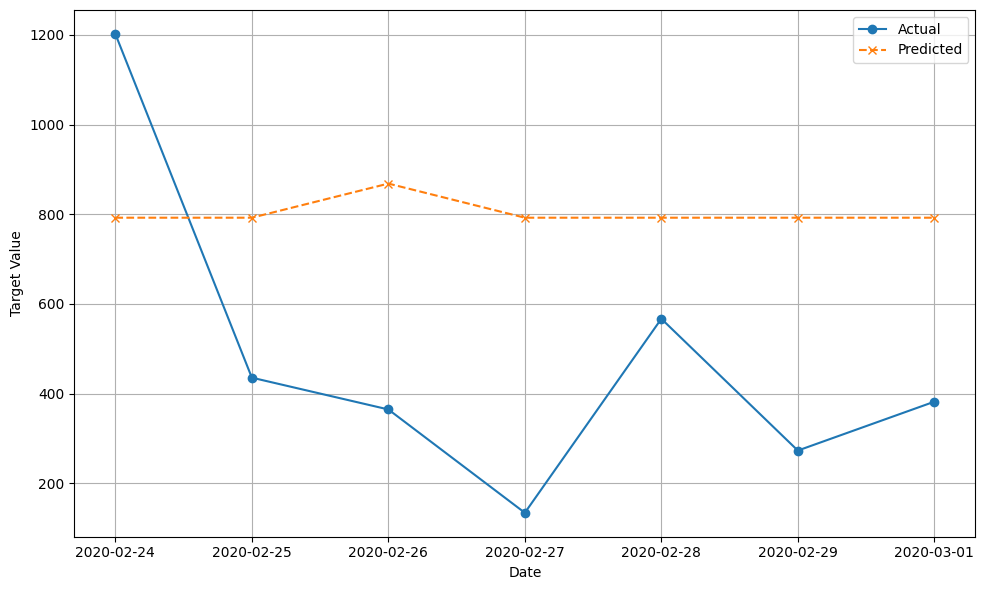


Fold 3 (771 train / 7 test)
MAE: 440.714, RMSE: 458.630, R2: -1.053


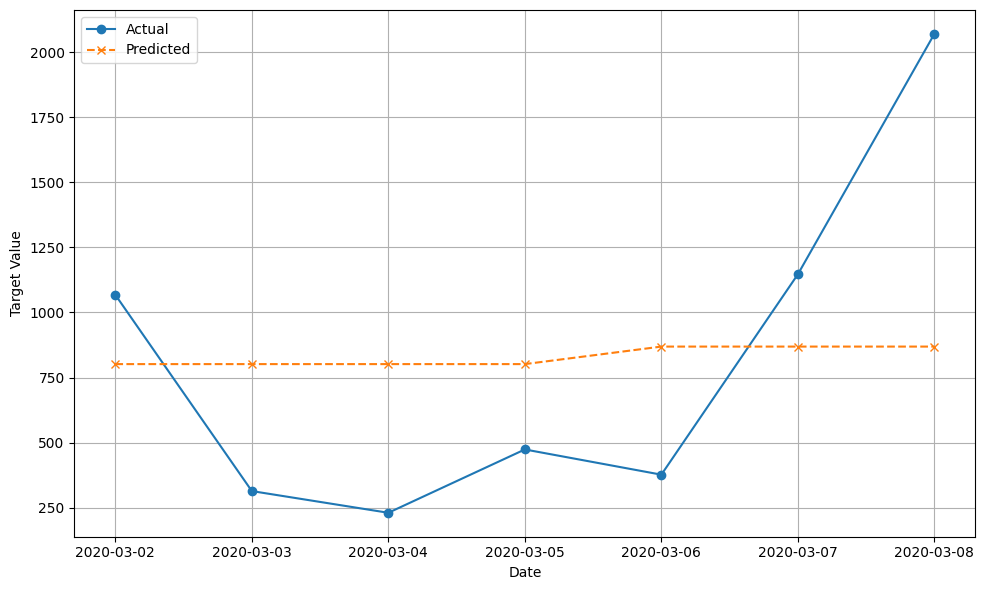


Fold 4 (778 train / 7 test)
MAE: 517.578, RMSE: 598.032, R2: 0.055


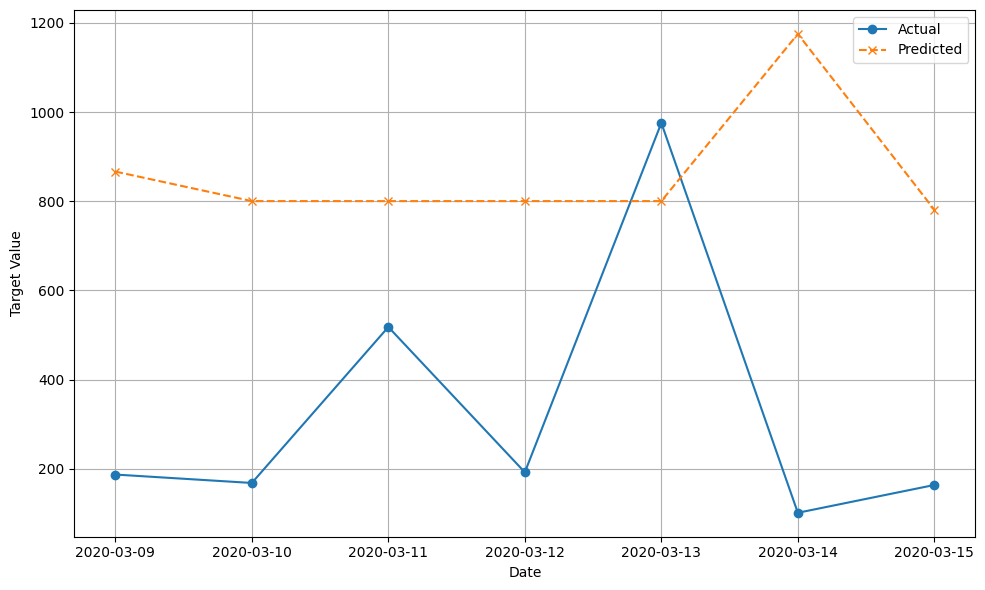


Fold 5 (785 train / 7 test)
MAE: 581.468, RMSE: 641.236, R2: -3.811

Average Metrics Across Folds:
MAE: 899.834
RMSE: 1238.093
R2: -1.083
mae_ratio: 1.103
Temporal Cross-Validation Results:


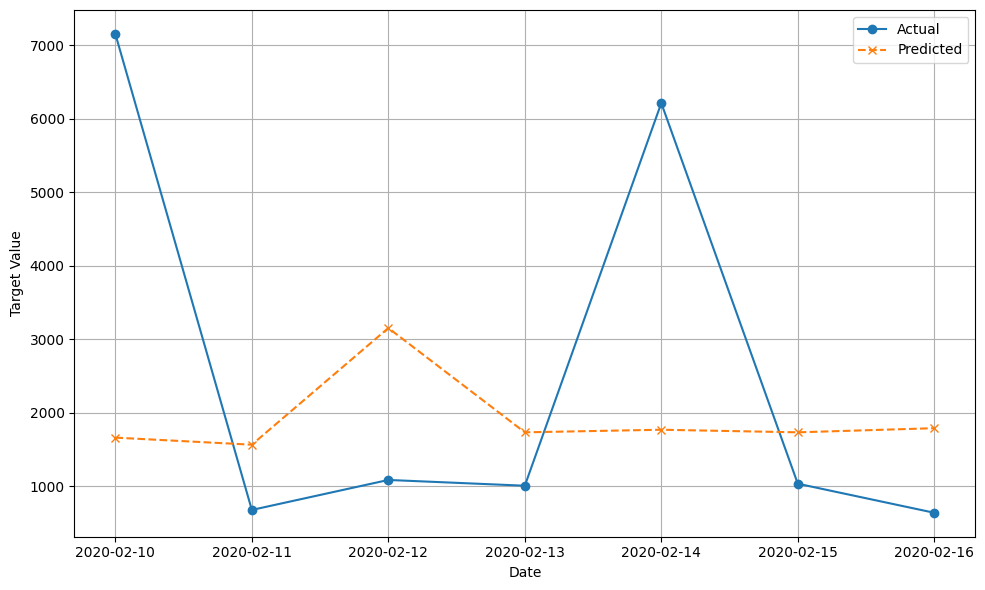


Fold 1 (769 train / 7 test)
MAE: 2210.200, RMSE: 2862.200, R2: -0.180


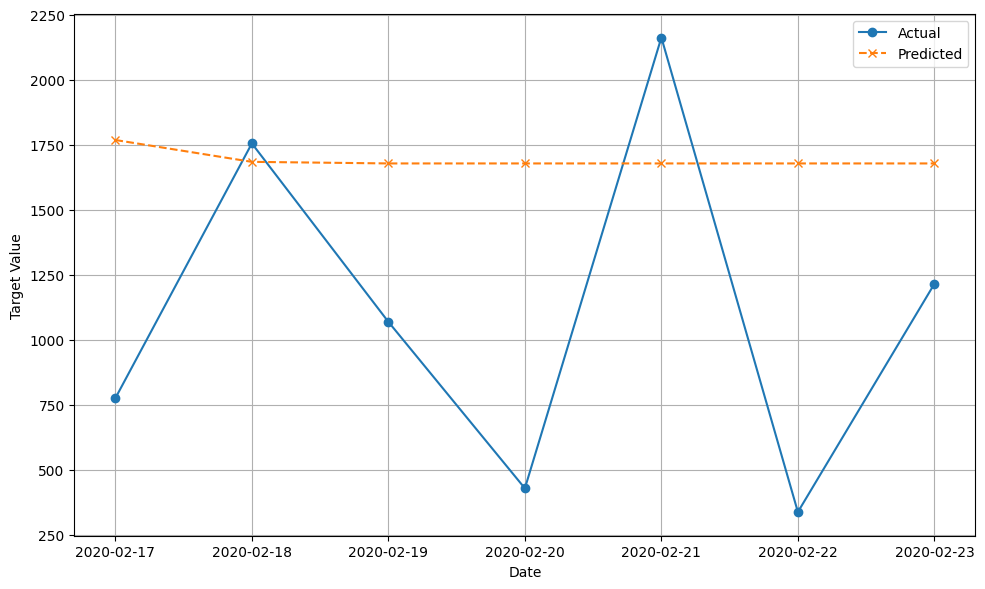


Fold 2 (776 train / 7 test)
MAE: 743.964, RMSE: 858.909, R2: -0.908


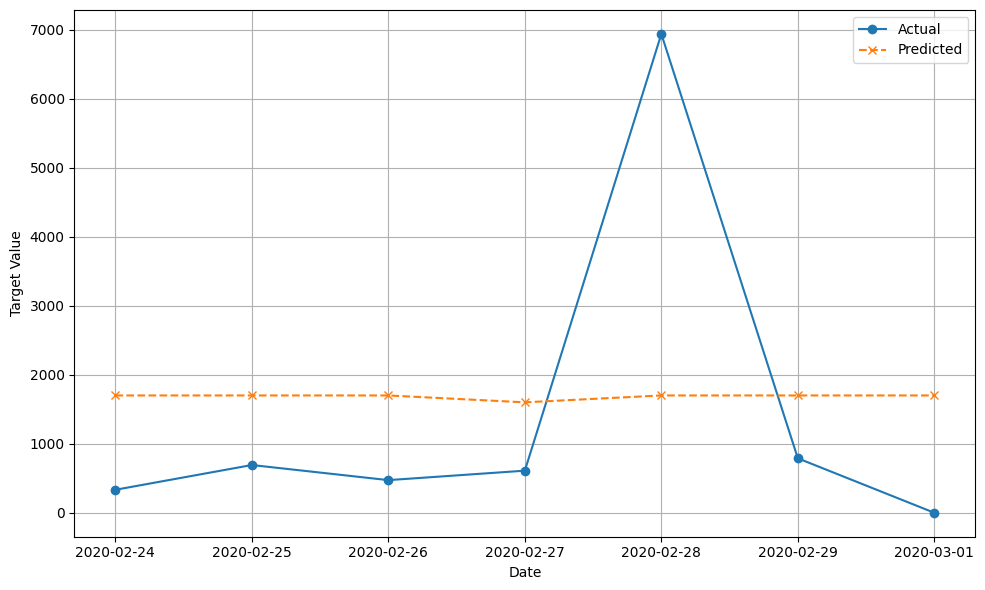


Fold 3 (783 train / 7 test)
MAE: 1776.851, RMSE: 2283.817, R2: -0.011


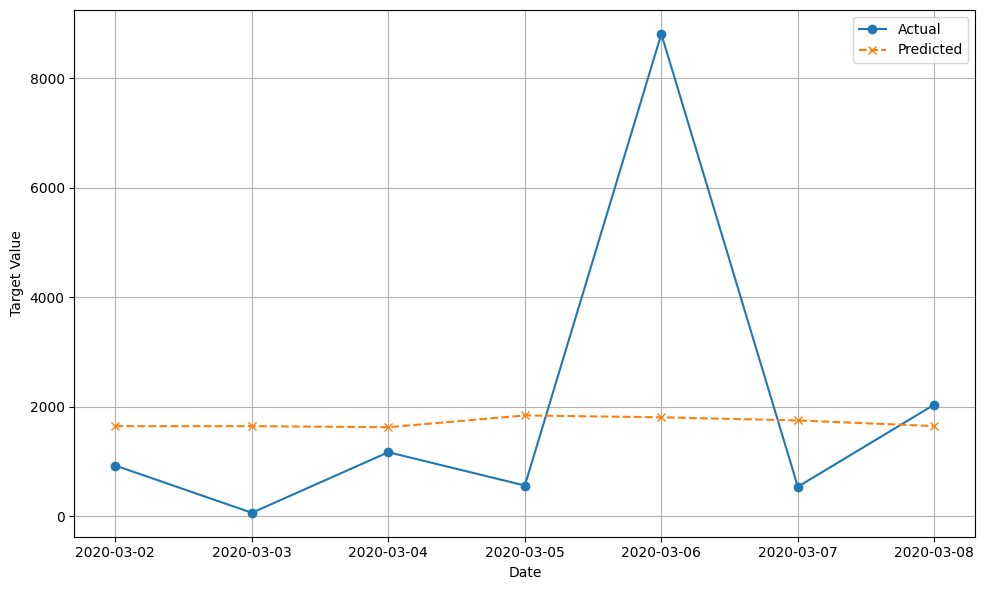


Fold 4 (790 train / 7 test)
MAE: 1806.821, RMSE: 2817.379, R2: 0.011


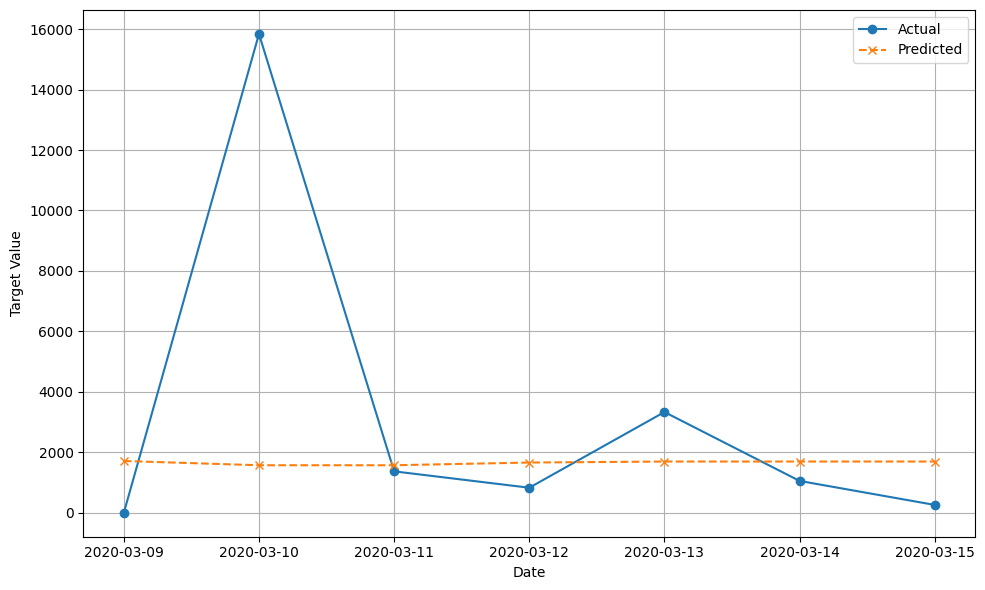


Fold 5 (797 train / 7 test)
MAE: 2961.652, RMSE: 5508.572, R2: -0.105

Average Metrics Across Folds:
MAE: 1899.897
RMSE: 2866.175
R2: -0.238
mae_ratio: 0.924
Temporal Cross-Validation Results:


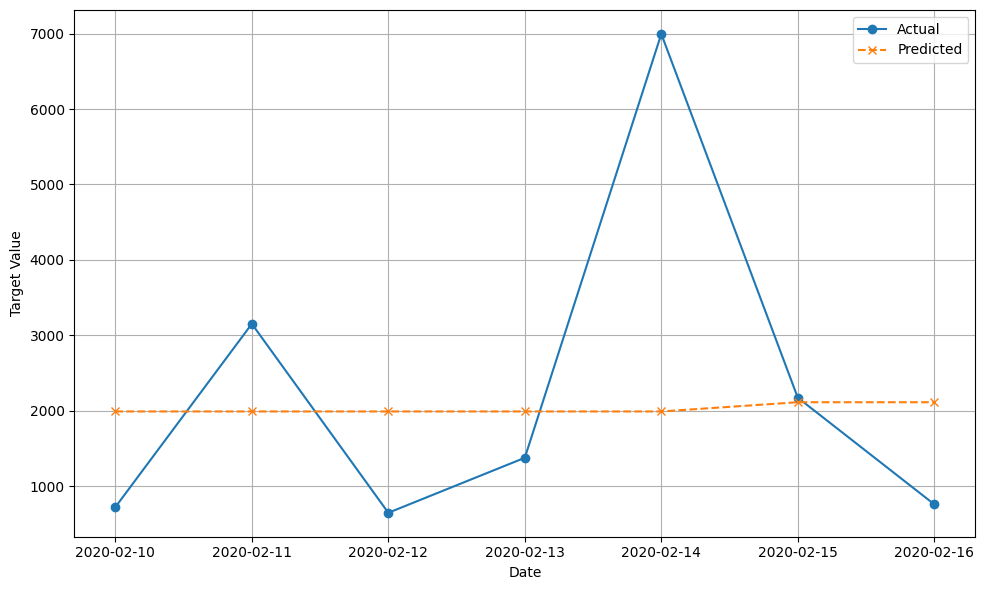


Fold 1 (745 train / 7 test)
MAE: 1544.011, RMSE: 2139.361, R2: -0.026


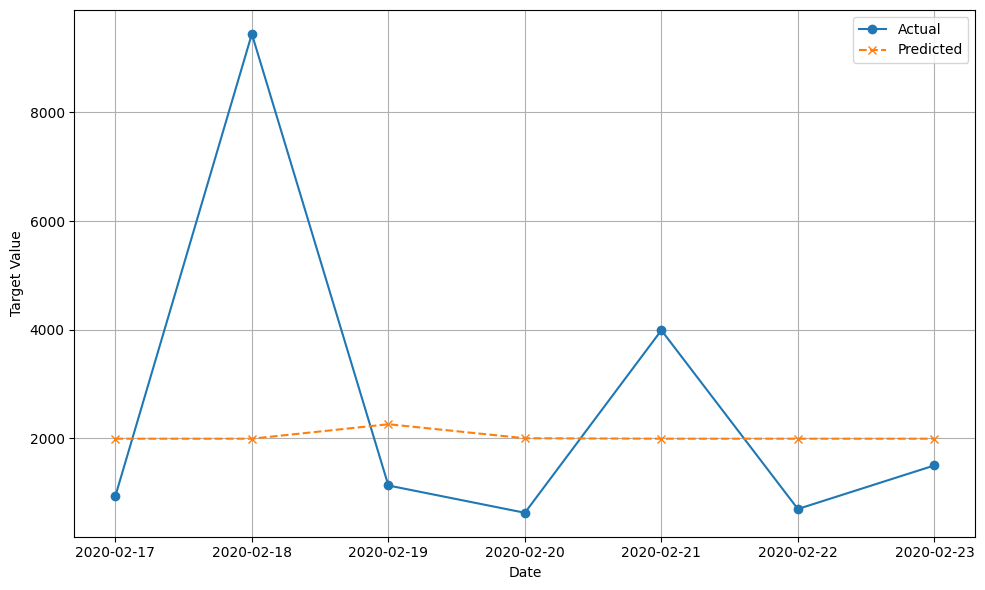


Fold 2 (752 train / 7 test)
MAE: 2113.208, RMSE: 3063.887, R2: -0.053


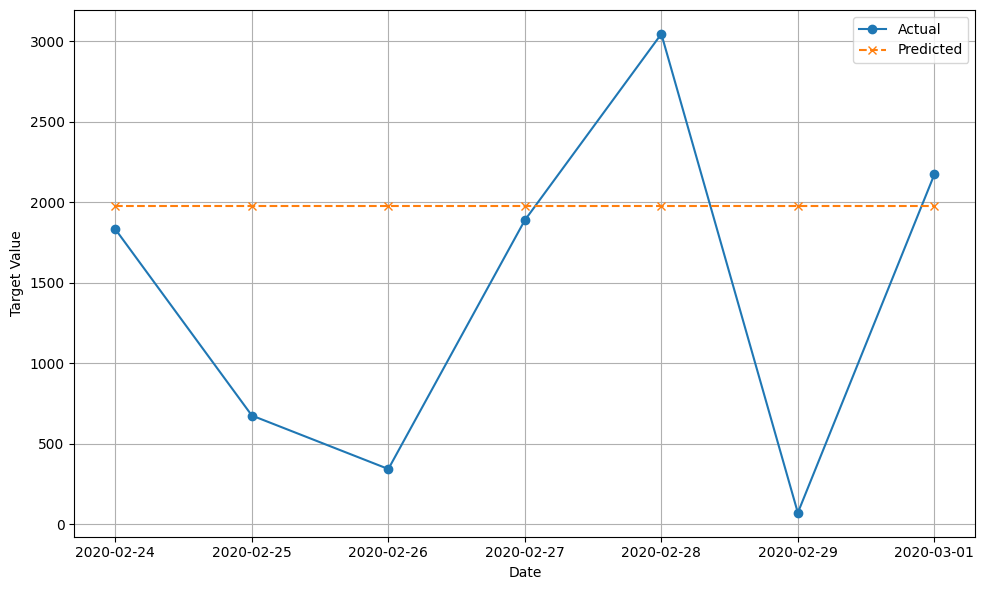


Fold 3 (759 train / 7 test)
MAE: 906.484, RMSE: 1147.817, R2: -0.294


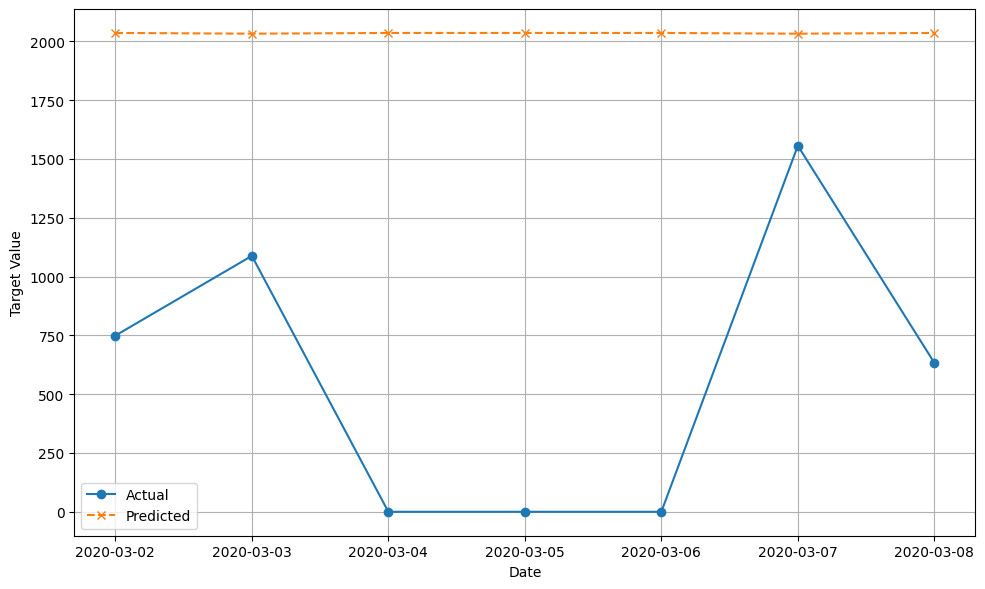


Fold 4 (766 train / 7 test)
MAE: 1459.687, RMSE: 1566.411, R2: -6.629


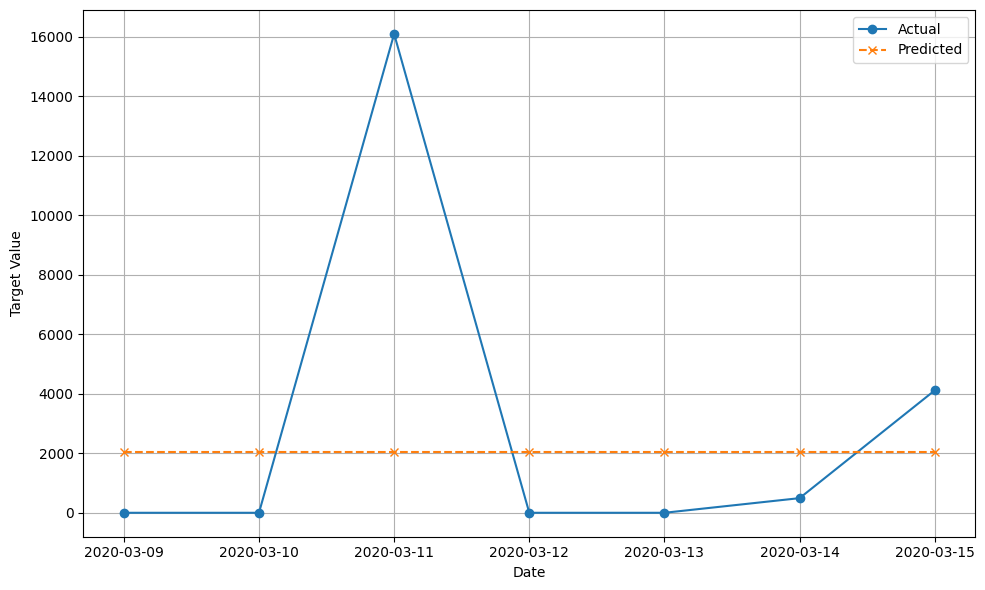


Fold 5 (773 train / 7 test)
MAE: 3687.633, RMSE: 5618.337, R2: -0.028

Average Metrics Across Folds:
MAE: 1942.205
RMSE: 2707.162
R2: -1.406
mae_ratio: 1.181


In [37]:
metrics = evaluate_model_on_clients(data, [2736675, 1926324, 207417] , model, params)

In [38]:
metrics

{2736675: {'avg_MAE': 899.8342209123884,
  'avg_MSE': 3065533.281982001,
  'avg_RMSE': 1238.0931071752477,
  'avg_R2': -1.083019679430595,
  'avg_mae_ratio': 1.103005229456557},
 1926324: {'avg_MAE': 1899.8973713727682,
  'avg_MSE': 10485544.49064275,
  'avg_RMSE': 2866.1754659362705,
  'avg_R2': -0.23841652504919794,
  'avg_mae_ratio': 0.9236158327635259},
 207417: {'avg_MAE': 1942.2047063337054,
  'avg_MSE': 9860219.61344229,
  'avg_RMSE': 2707.1622641864947,
  'avg_R2': -1.4057493712124955,
  'avg_mae_ratio': 1.181482078576375}}

In [39]:
mean_metrics = {
    'mean_MAE': np.mean([d['avg_MAE'] for k, d in metrics.items()]),
    'mean_MSE': np.mean([d['avg_MSE'] for k, d in metrics.items()]),
    'mean_RMSE': np.mean([d['avg_RMSE'] for k, d in metrics.items()]),
    'mean_R2': np.mean([d['avg_R2'] for k, d in metrics.items()]),
    'mean_mae_ratio': np.mean([d['avg_mae_ratio'] for k, d in metrics.items()])
}
mean_metrics

{'mean_MAE': 1580.6454328729542,
 'mean_MSE': 7803765.79535568,
 'mean_RMSE': 2270.476945766004,
 'mean_R2': -0.9090618585640962,
 'mean_mae_ratio': 1.0693677135988193}

Temporal Cross-Validation Results:


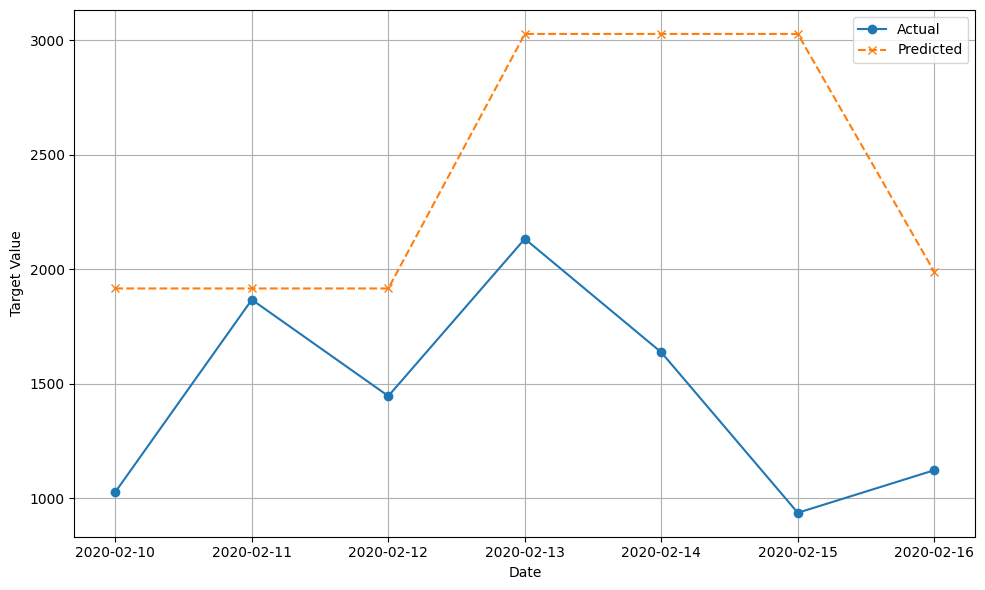


Fold 1 (686 train / 7 test)
MAE: 950.542, RMSE: 1126.267, R2: -6.242


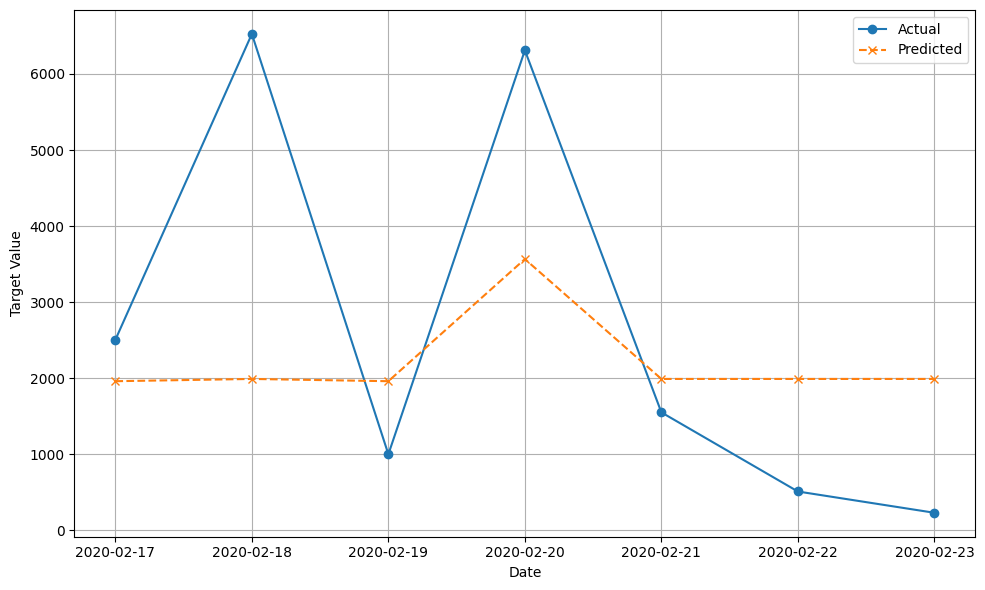


Fold 2 (693 train / 7 test)
MAE: 1781.864, RMSE: 2231.483, R2: 0.187


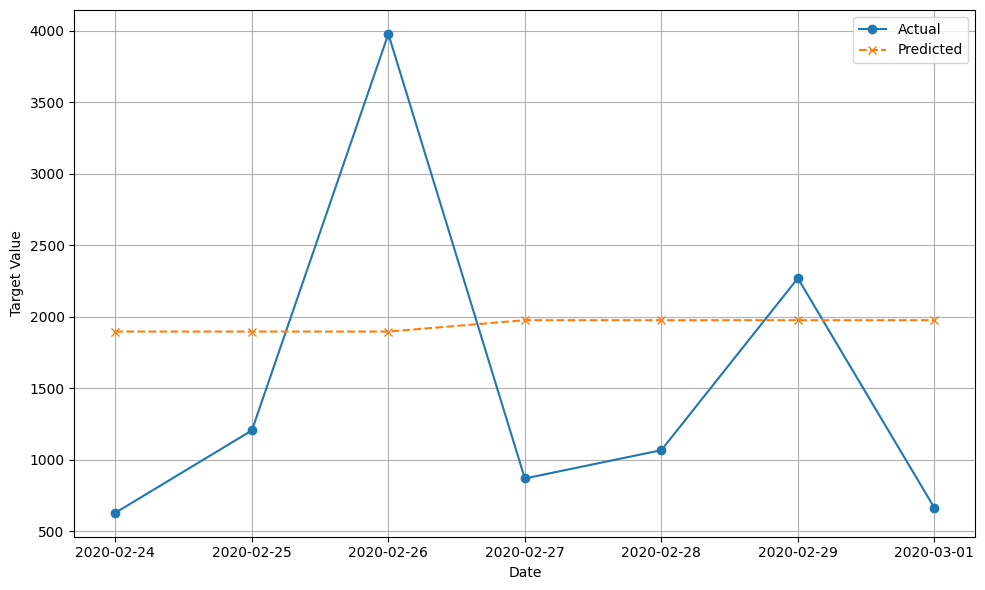


Fold 3 (700 train / 7 test)
MAE: 1095.023, RMSE: 1212.151, R2: -0.160


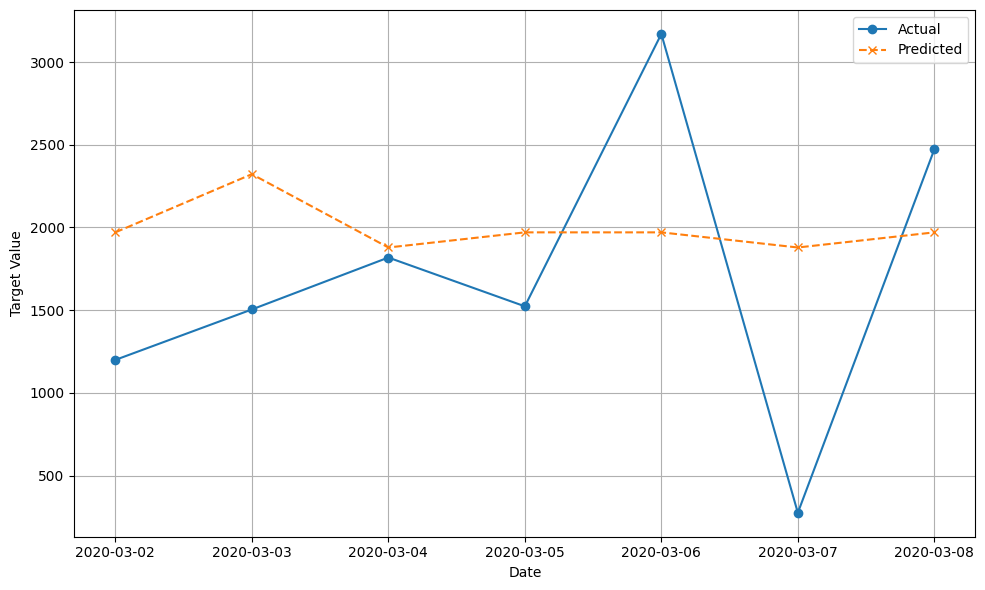


Fold 4 (707 train / 7 test)
MAE: 771.883, RMSE: 904.945, R2: -0.119


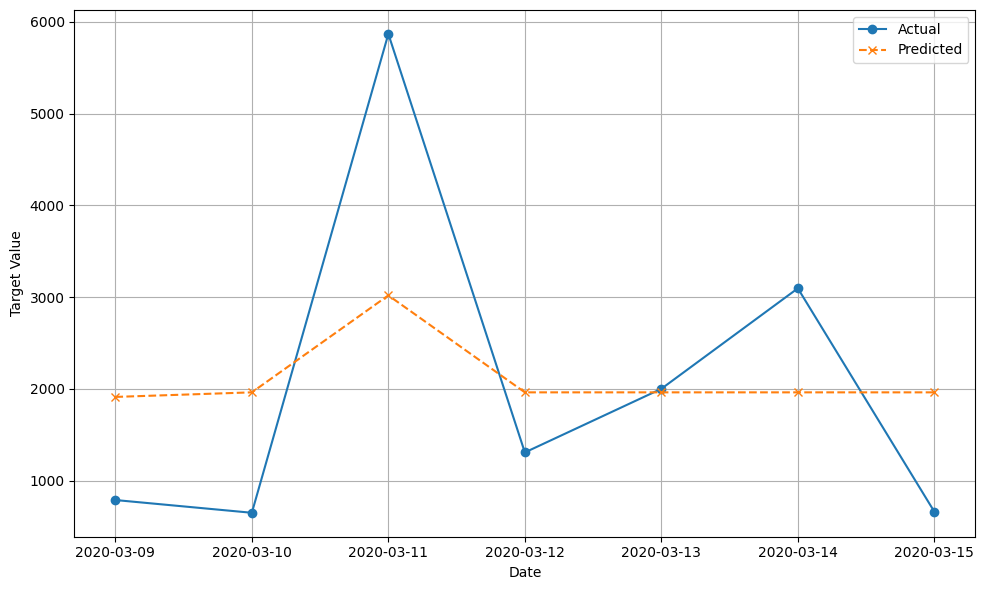


Fold 5 (714 train / 7 test)
MAE: 1202.641, RMSE: 1440.677, R2: 0.331

Average Metrics Across Folds:
MAE: 1160.391
RMSE: 1383.105
R2: -1.201
mae_ratio: 0.616
Temporal Cross-Validation Results:


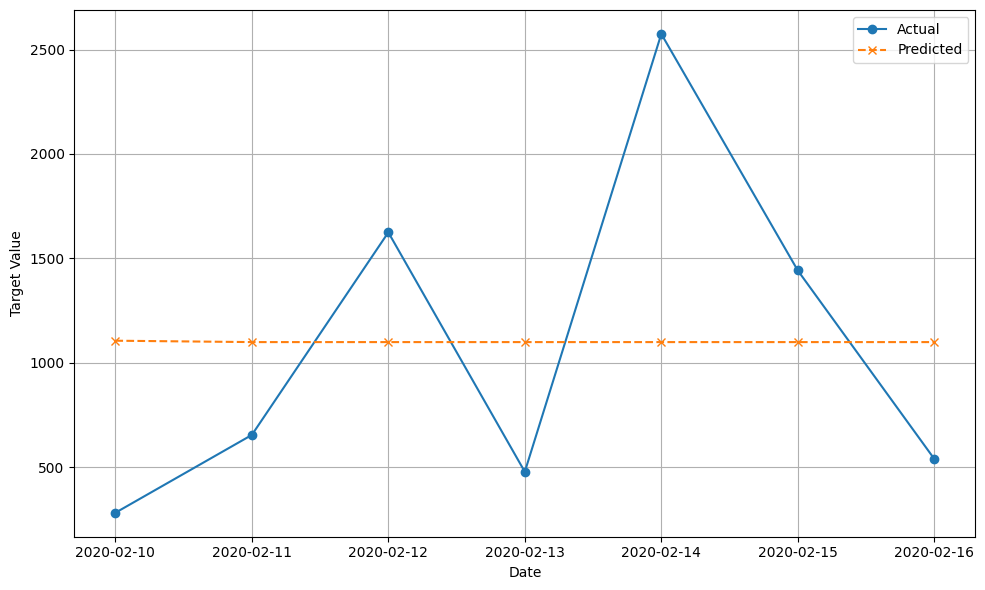


Fold 1 (769 train / 7 test)
MAE: 684.681, RMSE: 769.592, R2: -0.003


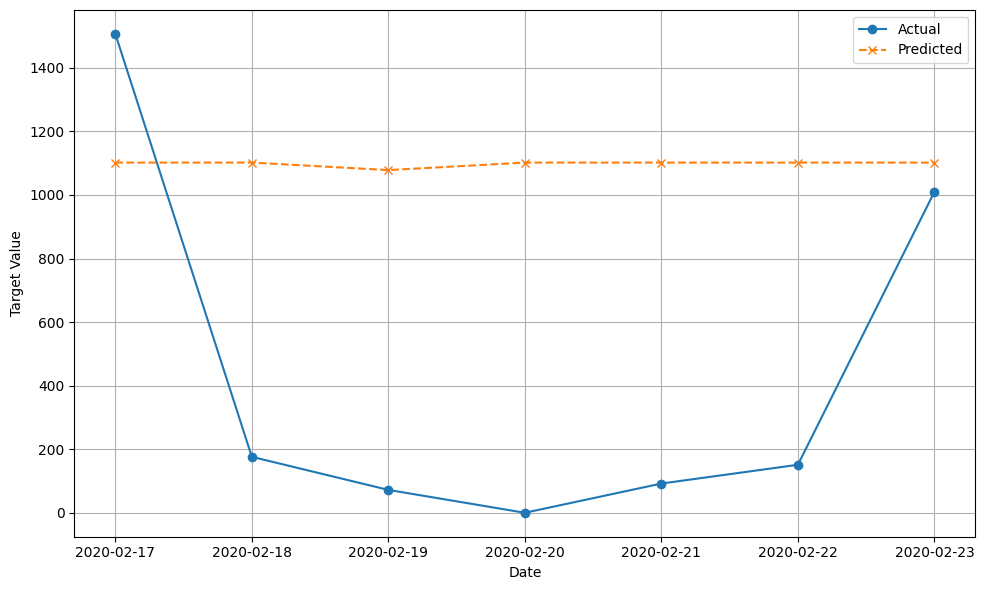


Fold 2 (776 train / 7 test)
MAE: 784.574, RMSE: 860.307, R2: -1.509


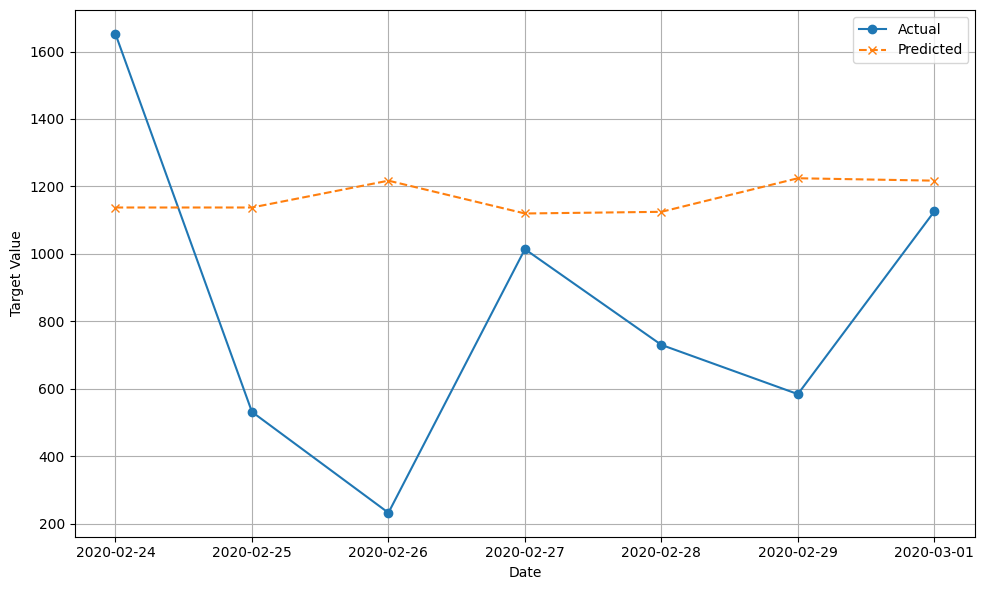


Fold 3 (783 train / 7 test)
MAE: 476.795, RMSE: 559.027, R2: -0.665


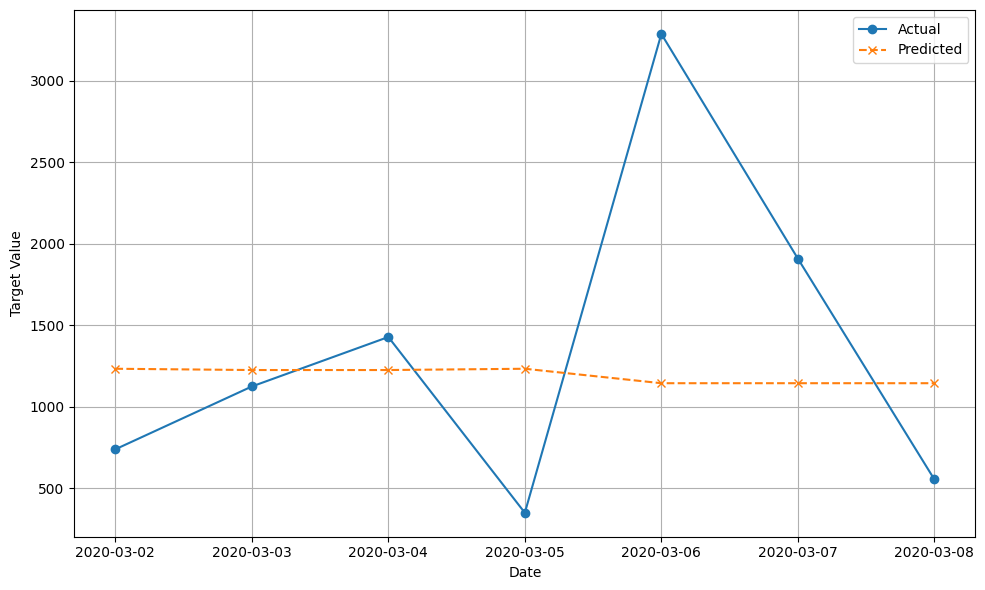


Fold 4 (790 train / 7 test)
MAE: 739.900, RMSE: 971.155, R2: -0.077


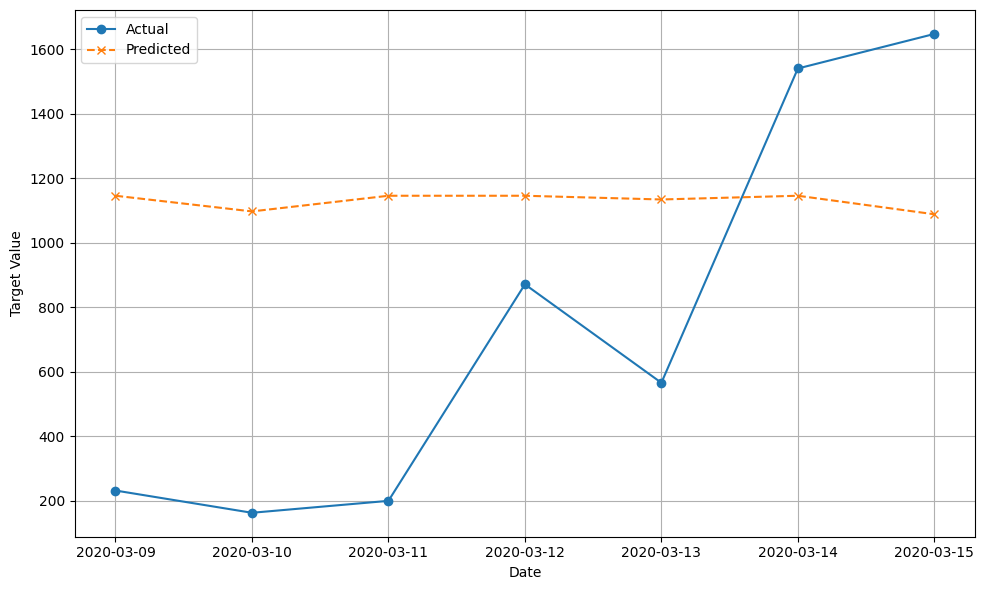


Fold 5 (797 train / 7 test)
MAE: 655.840, RMSE: 704.052, R2: -0.449

Average Metrics Across Folds:
MAE: 668.358
RMSE: 772.827
R2: -0.540
mae_ratio: 0.891
Temporal Cross-Validation Results:


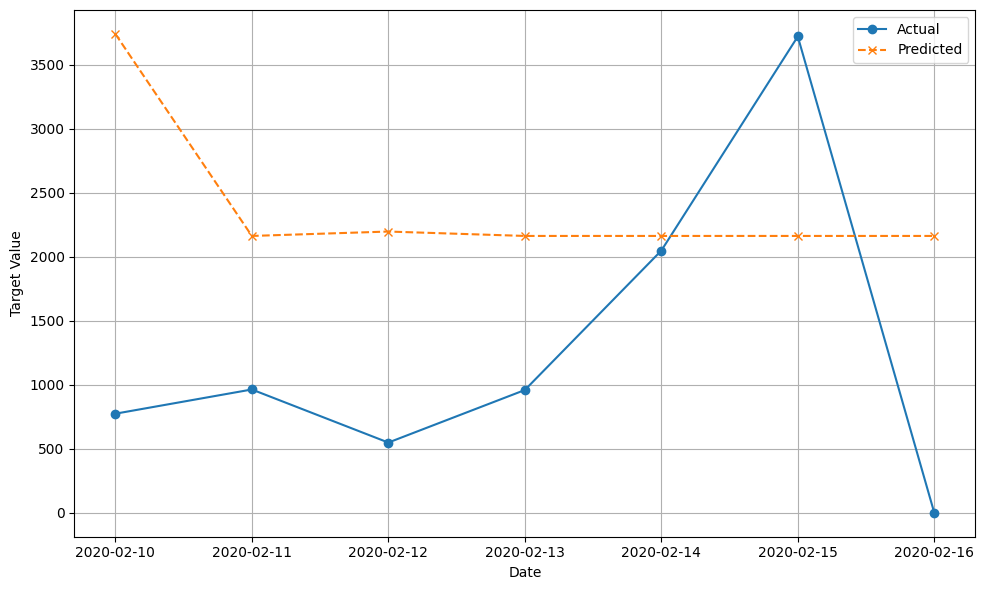


Fold 1 (770 train / 7 test)
MAE: 1550.571, RMSE: 1753.546, R2: -1.345


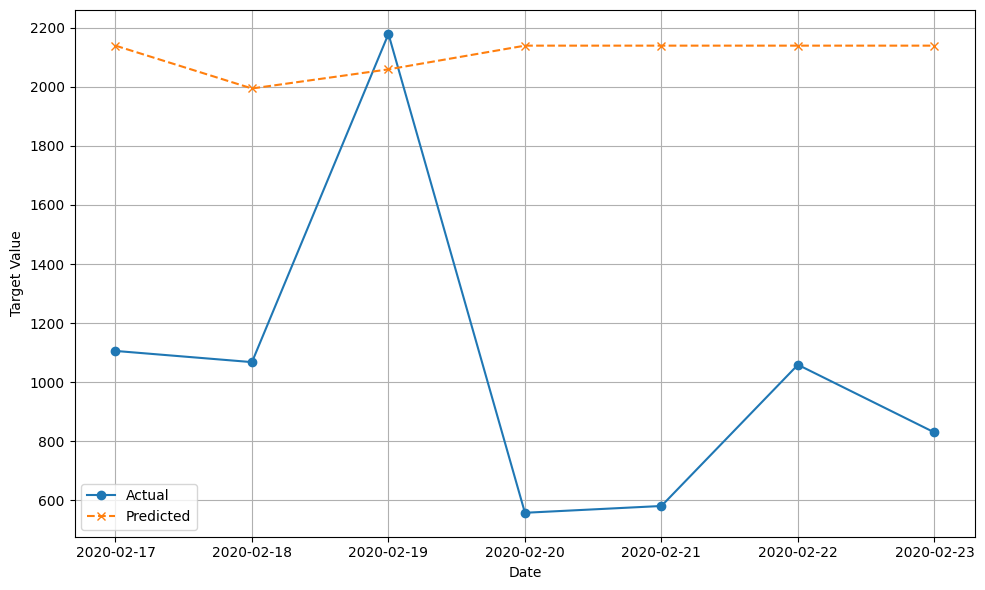


Fold 2 (777 train / 7 test)
MAE: 1087.027, RMSE: 1180.280, R2: -4.453


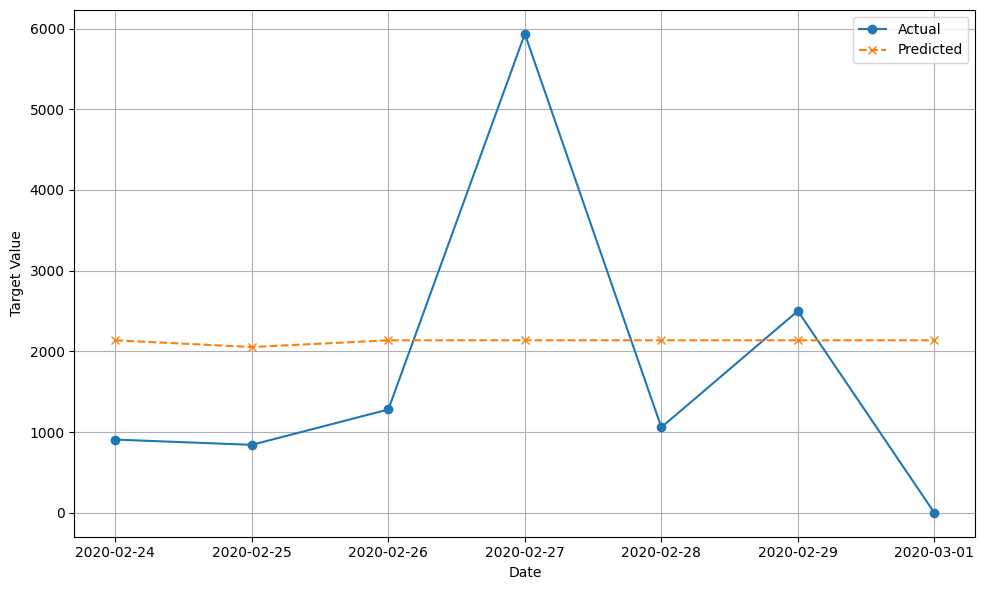


Fold 3 (784 train / 7 test)
MAE: 1524.978, RMSE: 1851.355, R2: -0.027


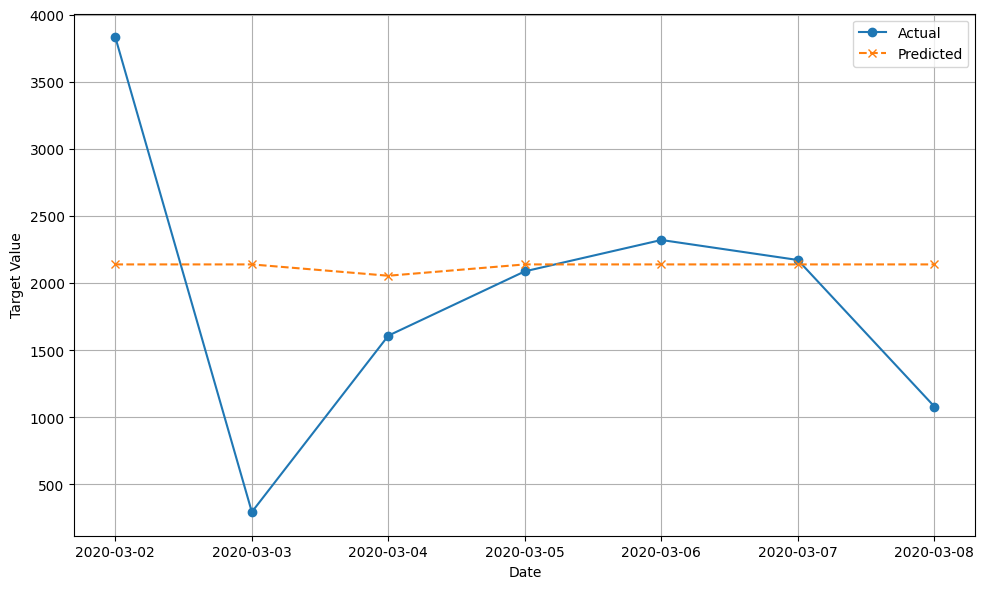


Fold 4 (791 train / 7 test)
MAE: 758.346, RMSE: 1043.561, R2: -0.037


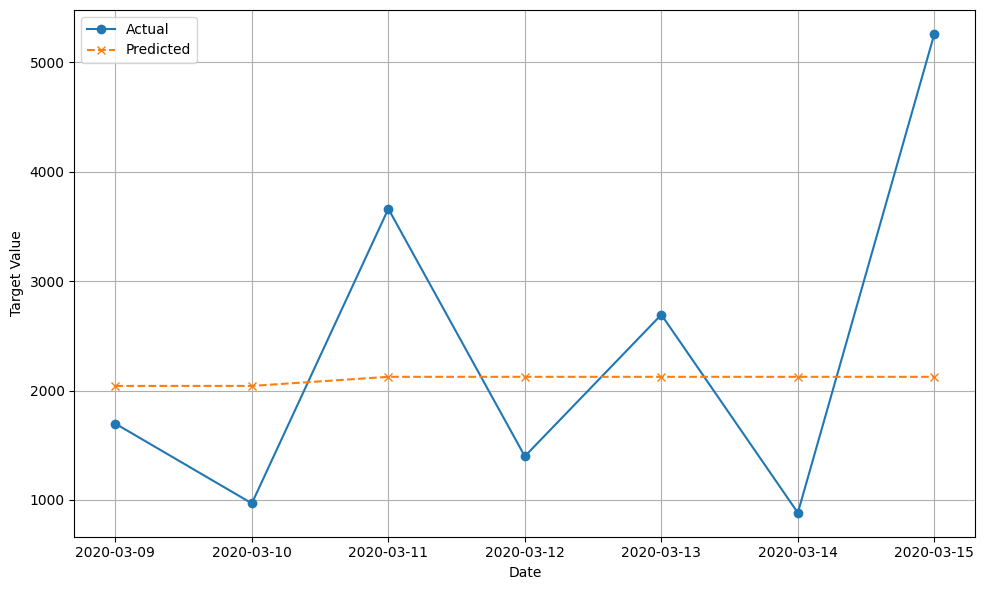


Fold 5 (798 train / 7 test)
MAE: 1231.542, RMSE: 1503.814, R2: -0.010

Average Metrics Across Folds:
MAE: 1230.493
RMSE: 1466.511
R2: -1.174
mae_ratio: 0.801
Temporal Cross-Validation Results:


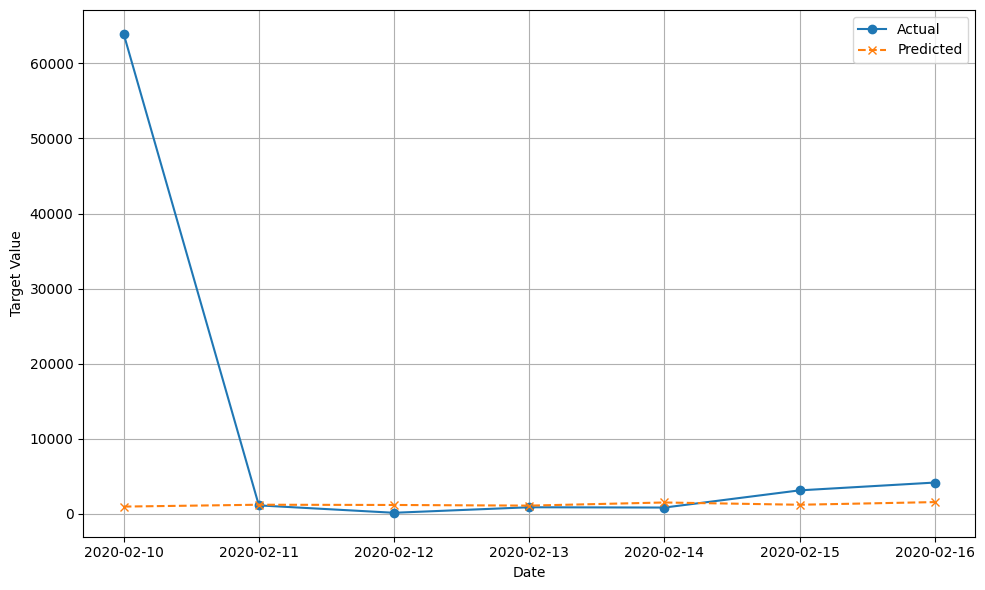


Fold 1 (704 train / 7 test)
MAE: 9928.981, RMSE: 23833.158, R2: -0.194


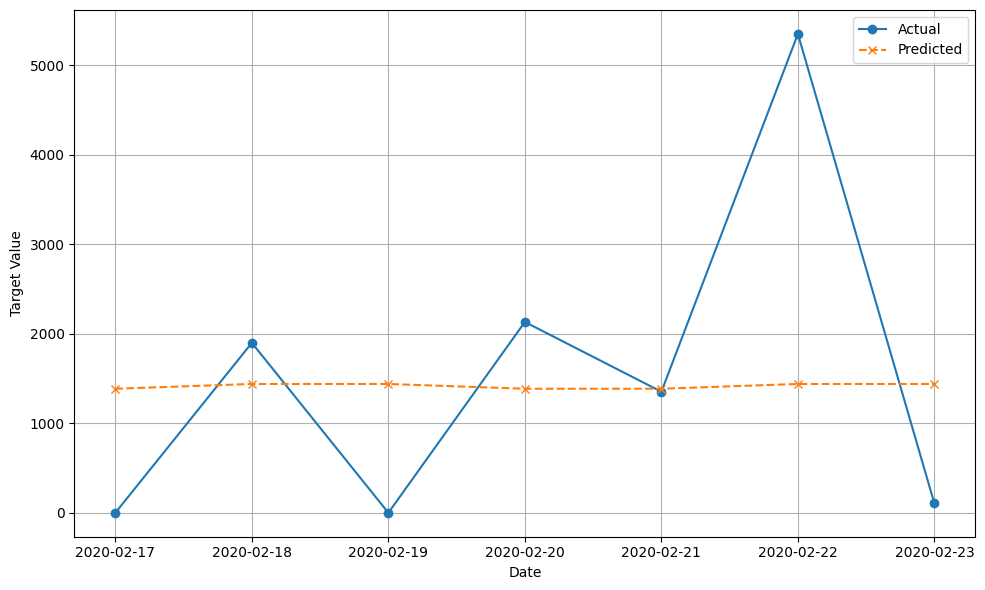


Fold 2 (711 train / 7 test)
MAE: 1329.588, RMSE: 1765.733, R2: -0.000


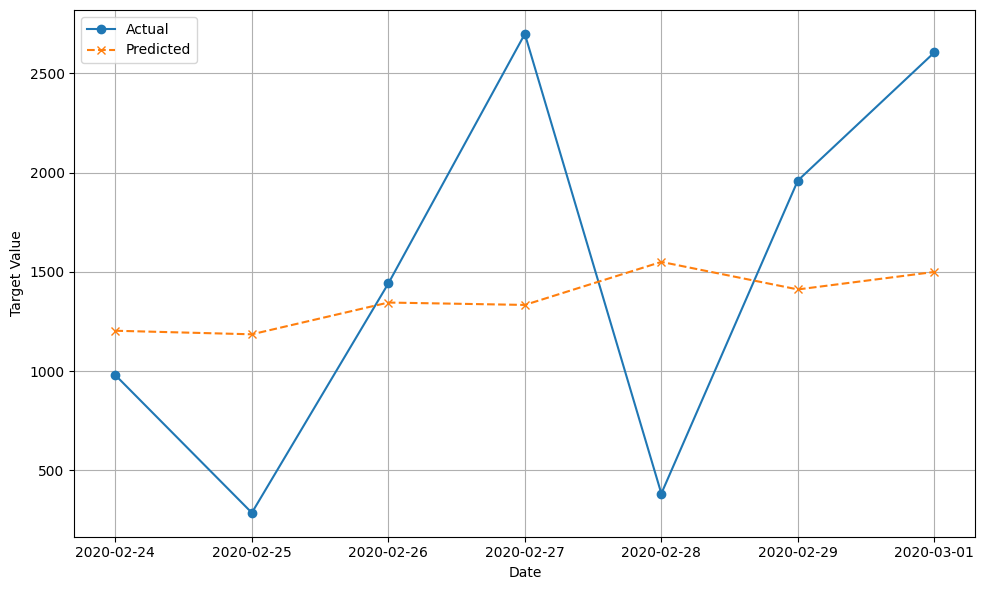


Fold 3 (718 train / 7 test)
MAE: 772.744, RMSE: 896.401, R2: 0.042


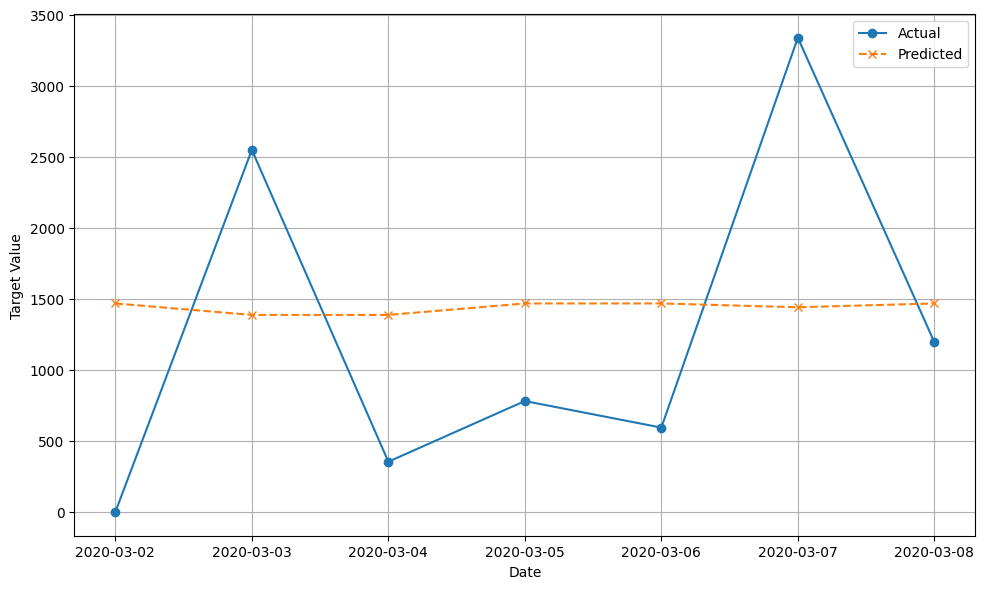


Fold 4 (725 train / 7 test)
MAE: 1055.716, RMSE: 1163.338, R2: -0.046


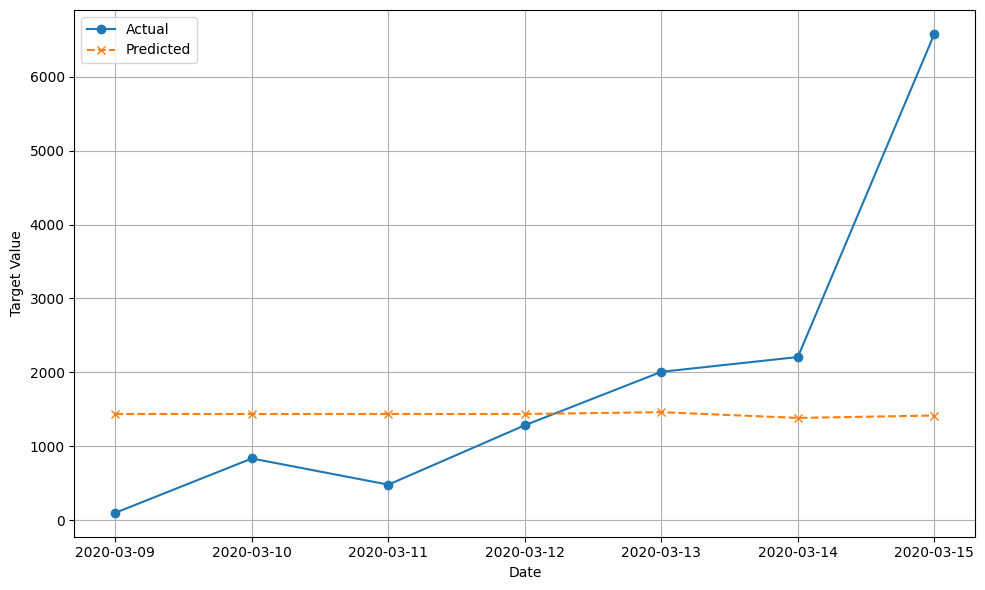


Fold 5 (732 train / 7 test)
MAE: 1369.829, RMSE: 2096.620, R2: -0.068

Average Metrics Across Folds:
MAE: 2891.372
RMSE: 5951.050
R2: -0.053
mae_ratio: 0.774
Temporal Cross-Validation Results:


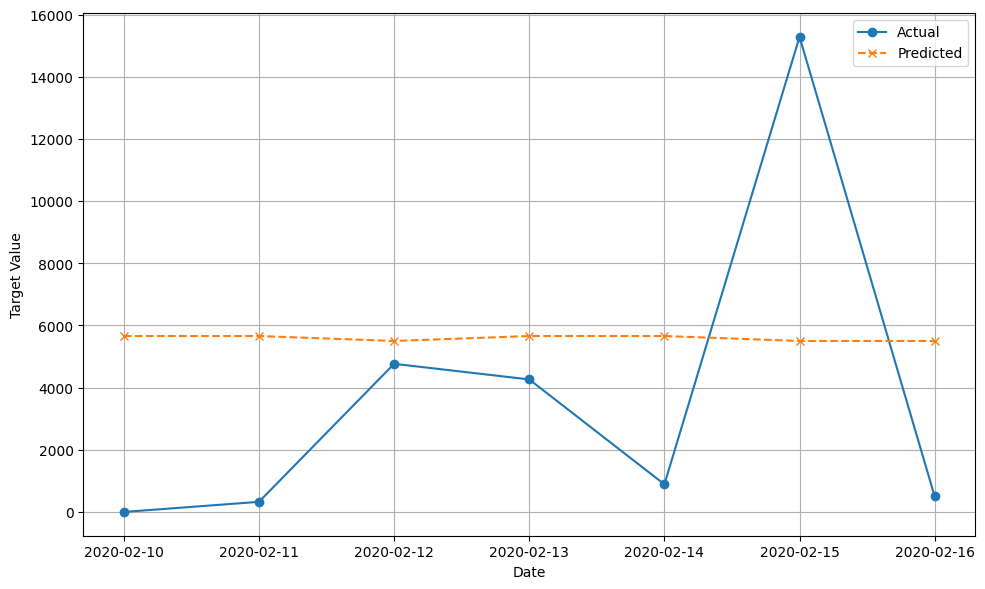


Fold 1 (768 train / 7 test)
MAE: 4669.713, RMSE: 5432.407, R2: -0.154


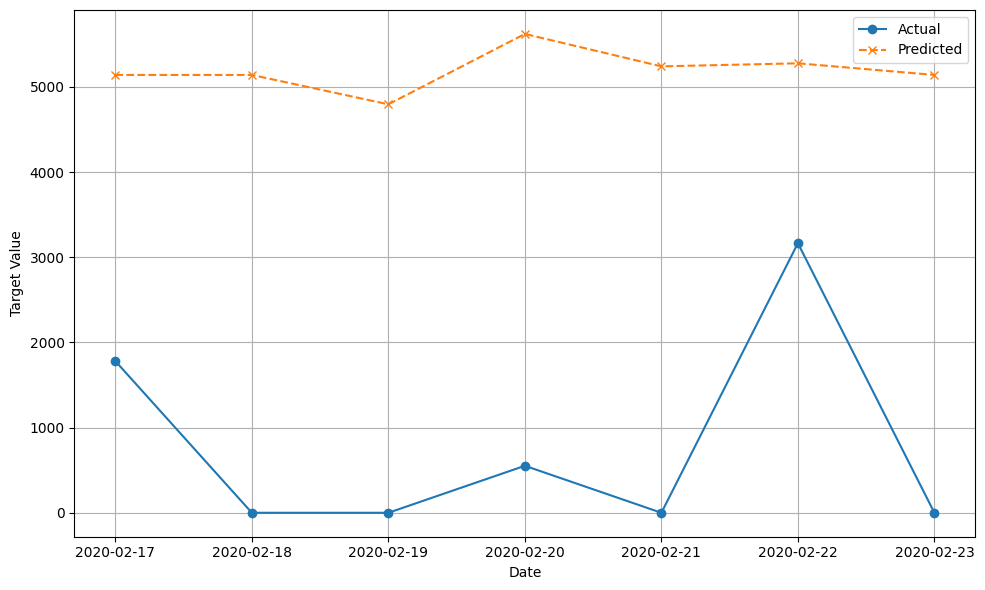


Fold 2 (775 train / 7 test)
MAE: 4408.096, RMSE: 4547.262, R2: -14.779


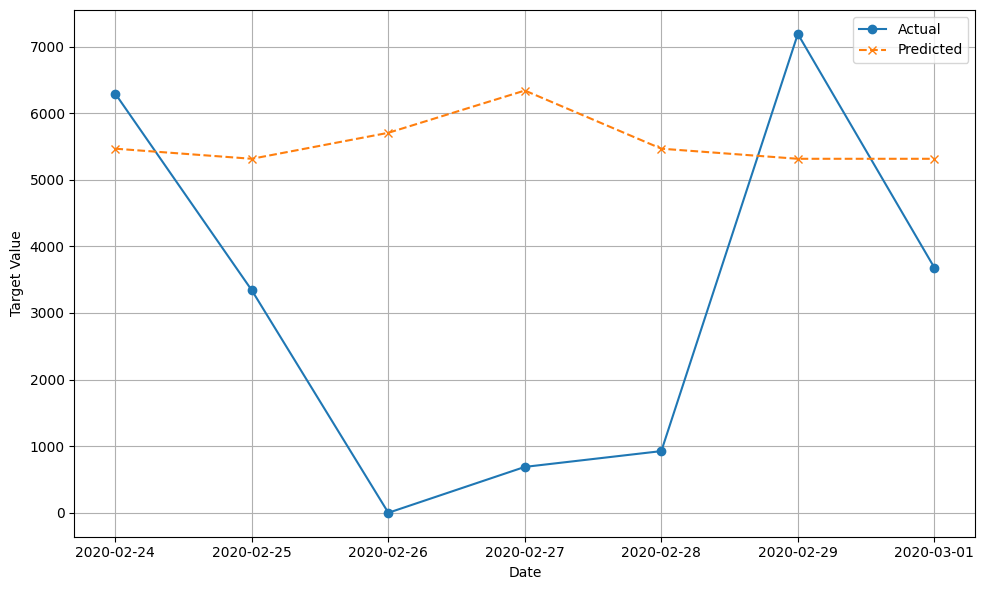


Fold 3 (782 train / 7 test)
MAE: 3171.944, RMSE: 3700.410, R2: -1.021


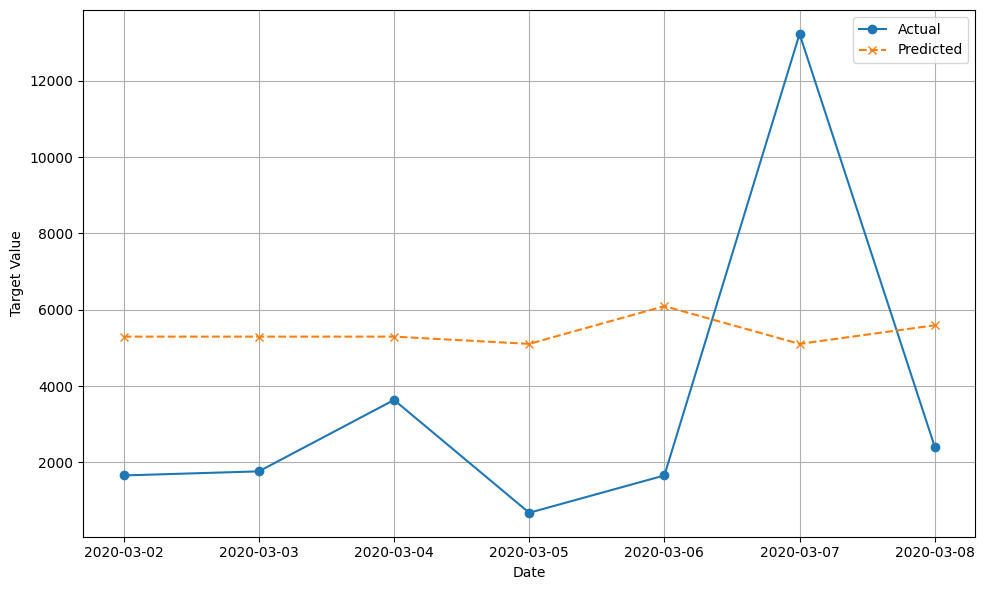


Fold 4 (789 train / 7 test)
MAE: 4141.954, RMSE: 4532.523, R2: -0.267


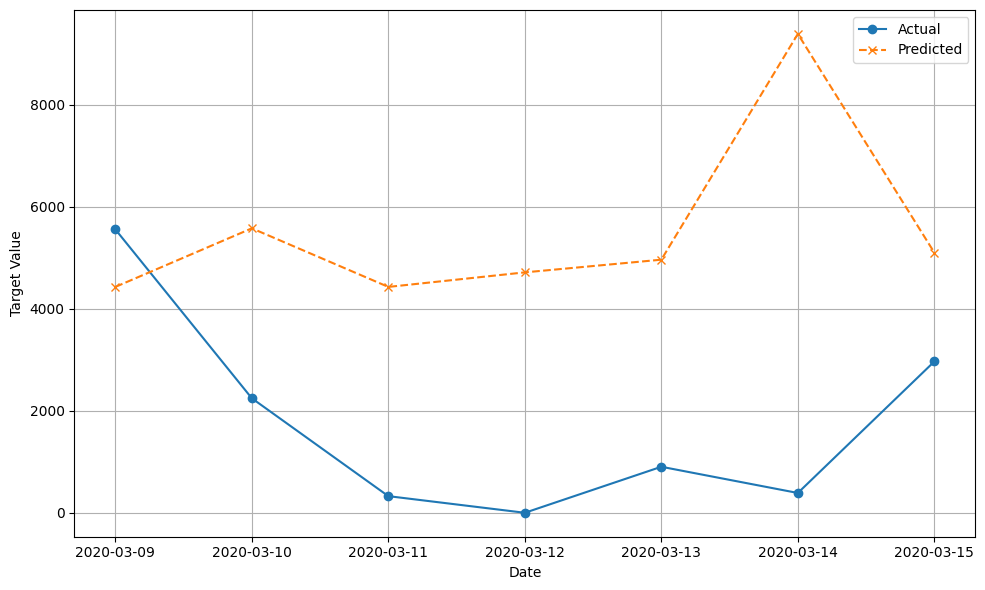


Fold 5 (796 train / 7 test)
MAE: 4065.303, RMSE: 4680.027, R2: -5.429

Average Metrics Across Folds:
MAE: 4091.402
RMSE: 4578.526
R2: -4.330
mae_ratio: 2.266


In [46]:
metrics_odd = evaluate_model_on_clients(data, [3377993, 1597439, 1662478, 3002740, 2853439] , model, params)

In [47]:
metrics_odd

{3377993: {'avg_MAE': 1160.3905114397319,
  'avg_MSE': 2122355.645567997,
  'avg_RMSE': 1383.104542648582,
  'avg_R2': -1.200609858831601,
  'avg_mae_ratio': 0.6158929622605708},
 1597439: {'avg_MAE': 668.3578713727678,
  'avg_MSE': 616748.5892285312,
  'avg_RMSE': 772.826688294426,
  'avg_R2': -0.5404632707904813,
  'avg_mae_ratio': 0.8912635784476022},
 1662478: {'avg_MAE': 1230.492814732143,
  'avg_MSE': 2249195.23000828,
  'avg_RMSE': 1466.5112051199255,
  'avg_R2': -1.1743813311843134,
  'avg_mae_ratio': 0.8009207916311324},
 3002740: {'avg_MAE': 2891.371641671317,
  'avg_MSE': 115537983.26268819,
  'avg_RMSE': 5951.049868878943,
  'avg_R2': -0.0532555424185883,
  'avg_mae_ratio': 0.7736166886083832},
 2853439: {'avg_MAE': 4091.4018560267855,
  'avg_MSE': 21265618.88168731,
  'avg_RMSE': 4578.525893533096,
  'avg_R2': -4.330116600601324,
  'avg_mae_ratio': 2.2659700265196134}}

In [48]:
mean_metrics_odd = {
    'mean_MAE': np.mean([d['avg_MAE'] for k, d in metrics_odd.items()]),
    'mean_MSE': np.mean([d['avg_MSE'] for k, d in metrics_odd.items()]),
    'mean_RMSE': np.mean([d['avg_RMSE'] for k, d in metrics_odd.items()]),
    'mean_R2': np.mean([d['avg_R2'] for k, d in metrics_odd.items()]),
    'mean_mae_ratio': np.mean([d['avg_mae_ratio'] for k, d in metrics_odd.items()])
}
mean_metrics_odd

{'mean_MAE': 2008.402939048549,
 'mean_MSE': 28358380.32183606,
 'mean_RMSE': 2830.4036396949946,
 'mean_R2': -1.4597653207652617,
 'mean_mae_ratio': 1.0695328094934604}

In [40]:
import pandas as pd
import numpy as np

class HistoricalMeanBaseline:
    def __init__(self):
        self.day_means = pd.Series(dtype=float)
        self.overall_mean = 0.0
    
    def fit(self, X, y):
        """Update model with historical day-of-week averages from the data"""
#         day_of_week = X['day_of_week']
#         self.day_means = y.groupby(day_of_week).mean()
#         self.overall_mean = y.mean()
        self.mean = y.mean()
    
    def predict(self, X):
        """Predict using historical day-of-week averages"""
#         day_of_week = X['day_of_week']
#         predictions = day_of_week.map(self.day_means).fillna(self.overall_mean)
#         return predictions.to_numpy()
        return np.array([self.mean for i in range(len(X))])

Temporal Cross-Validation Results:
Series([], dtype: float64)
0.0


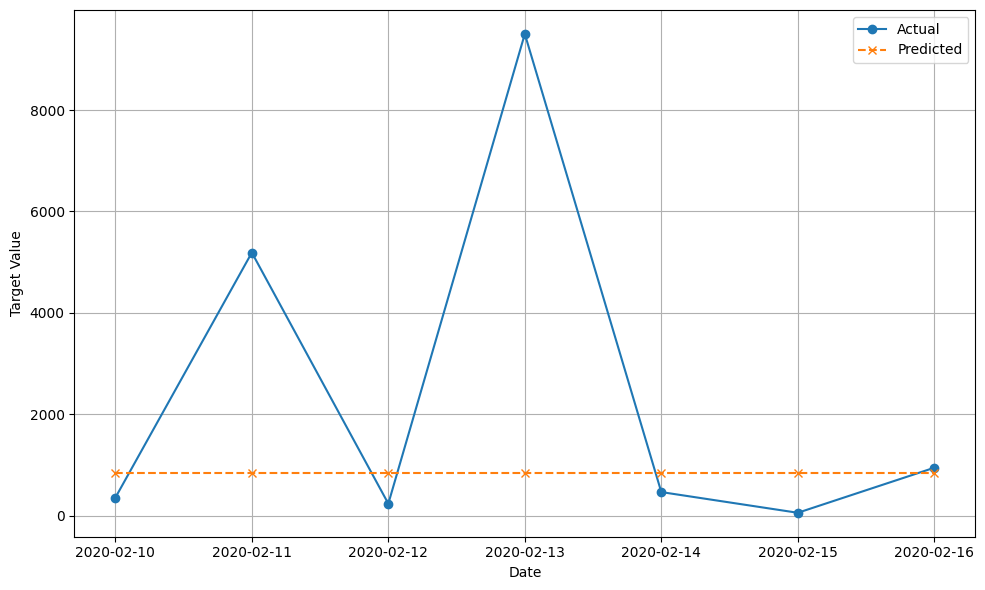


Fold 1 (757 train / 7 test)
MAE: 2196.171, RMSE: 3687.719, R2: -0.213
Series([], dtype: float64)
0.0


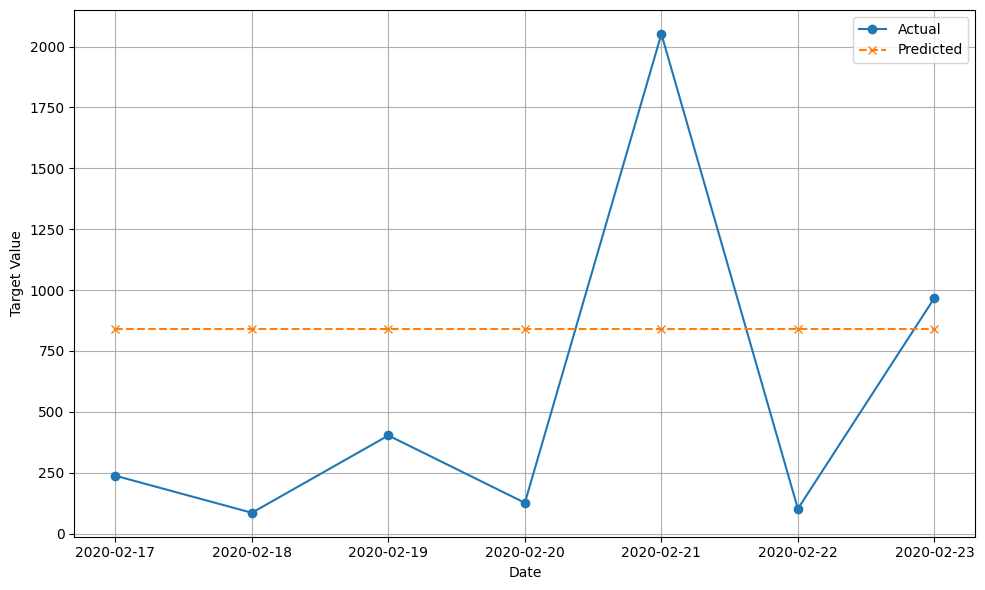


Fold 2 (764 train / 7 test)
MAE: 655.331, RMSE: 723.575, R2: -0.166
Series([], dtype: float64)
0.0


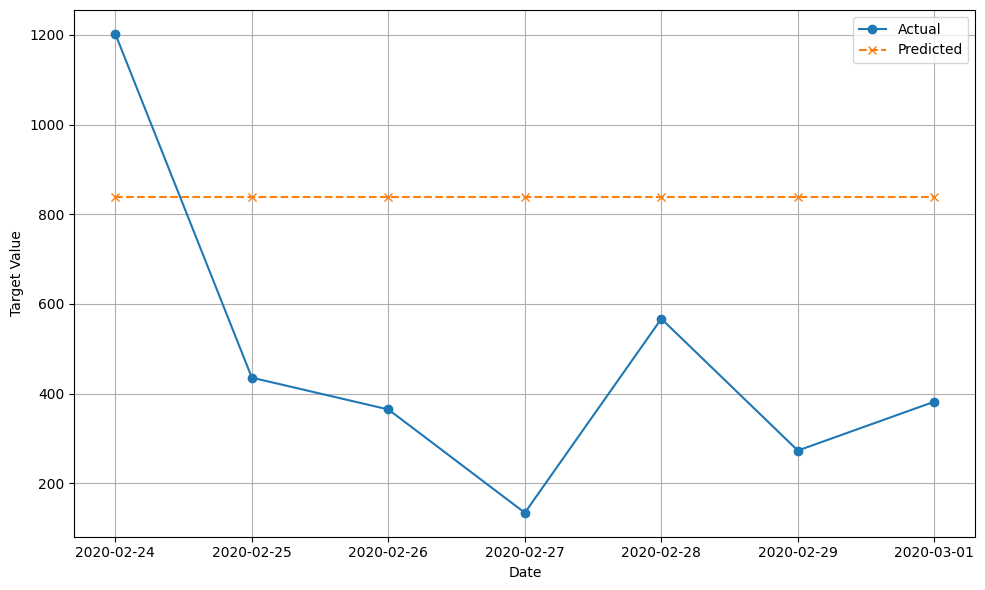


Fold 3 (771 train / 7 test)
MAE: 462.294, RMSE: 480.300, R2: -1.252
Series([], dtype: float64)
0.0


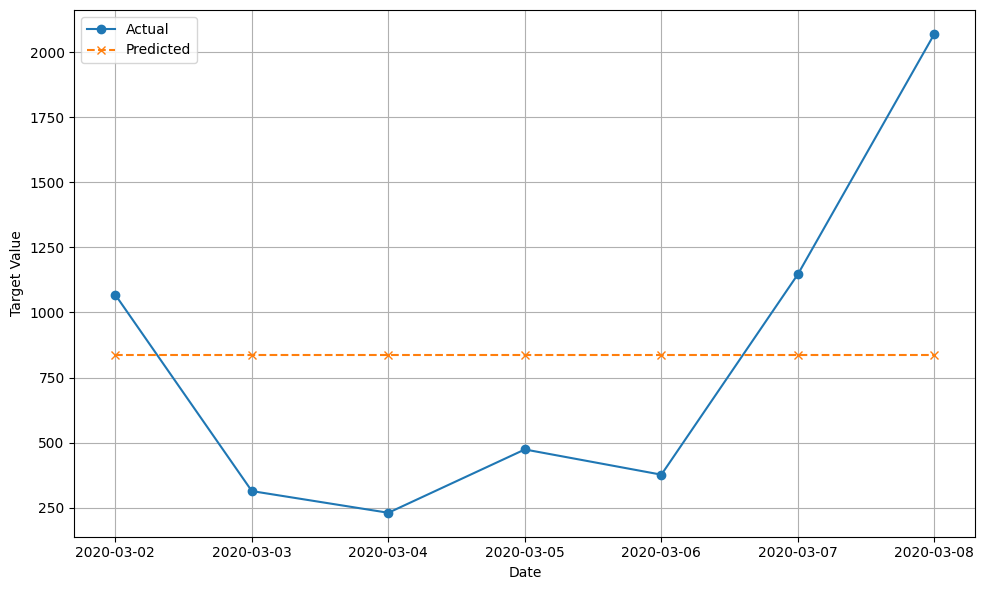


Fold 4 (778 train / 7 test)
MAE: 532.147, RMSE: 615.691, R2: -0.002
Series([], dtype: float64)
0.0


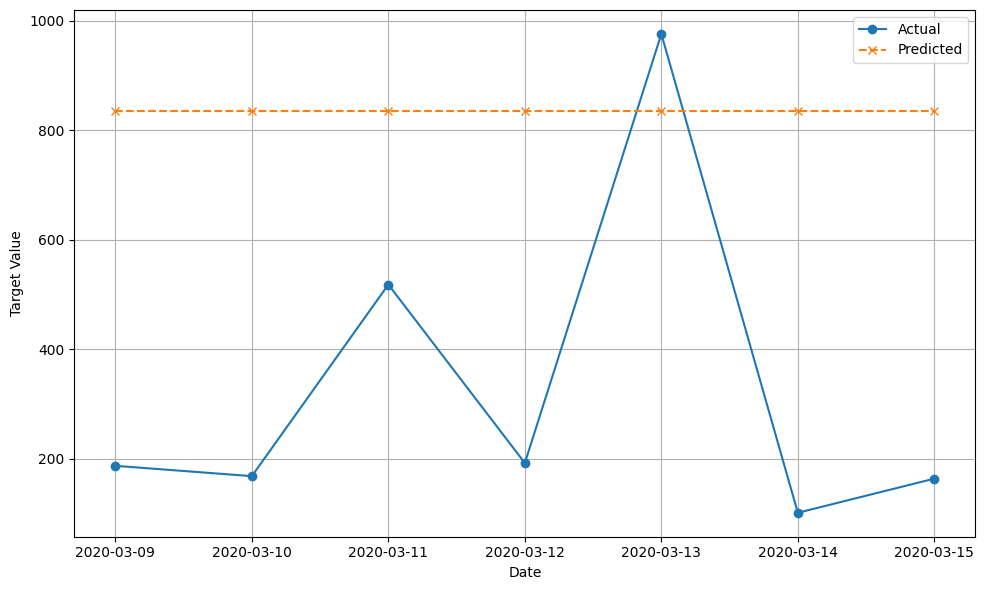


Fold 5 (785 train / 7 test)
MAE: 545.731, RMSE: 583.896, R2: -2.989

Average Metrics Across Folds:
MAE: 878.335
RMSE: 1218.236
R2: -0.924
mae_ratio: 1.070
Temporal Cross-Validation Results:
Series([], dtype: float64)
0.0


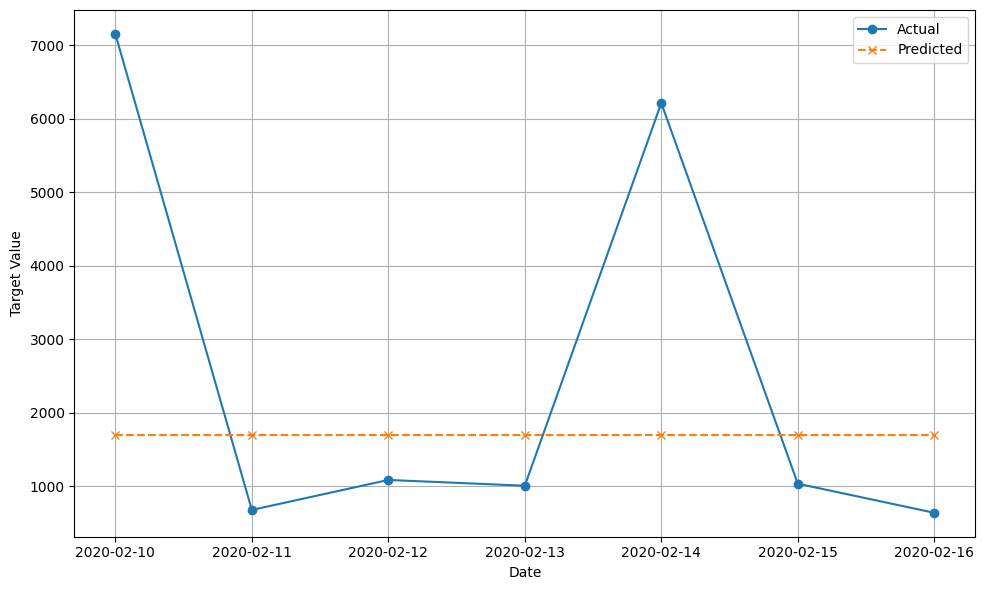


Fold 1 (769 train / 7 test)
MAE: 2004.707, RMSE: 2766.676, R2: -0.102
Series([], dtype: float64)
0.0


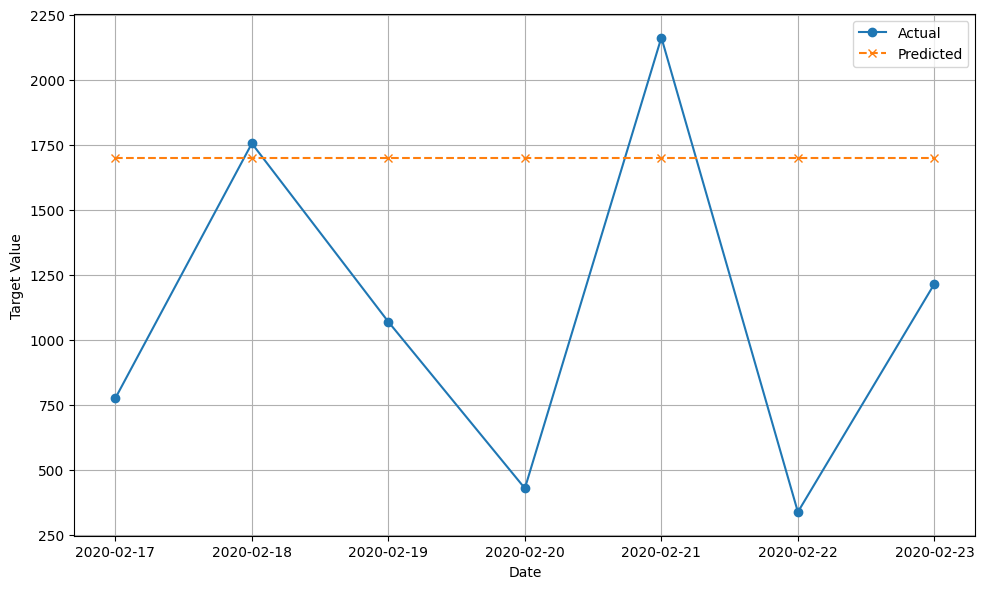


Fold 2 (776 train / 7 test)
MAE: 741.637, RMSE: 860.096, R2: -0.913
Series([], dtype: float64)
0.0


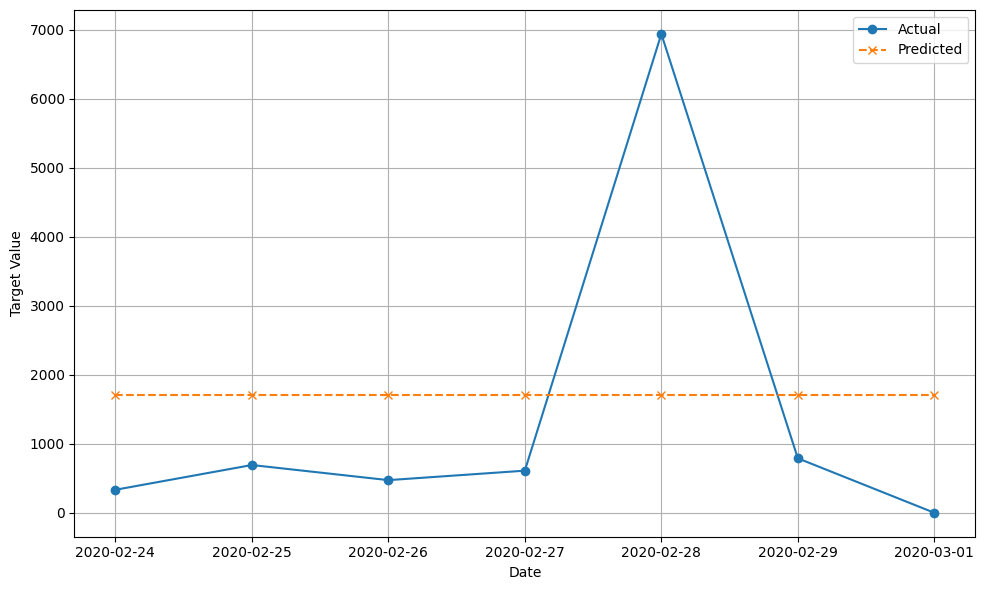


Fold 3 (783 train / 7 test)
MAE: 1793.564, RMSE: 2290.737, R2: -0.017
Series([], dtype: float64)
0.0


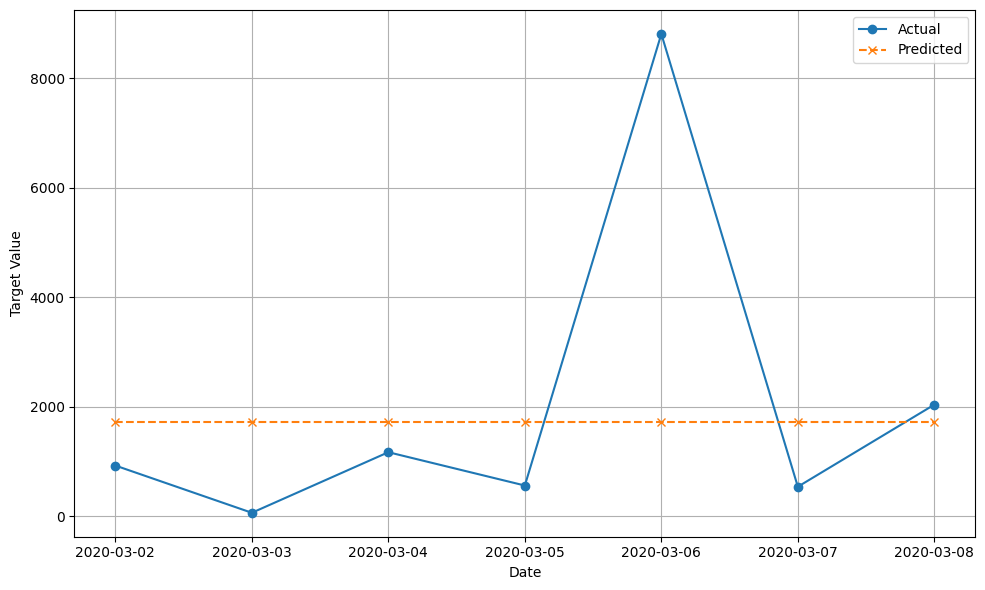


Fold 4 (790 train / 7 test)
MAE: 1818.765, RMSE: 2849.784, R2: -0.011
Series([], dtype: float64)
0.0


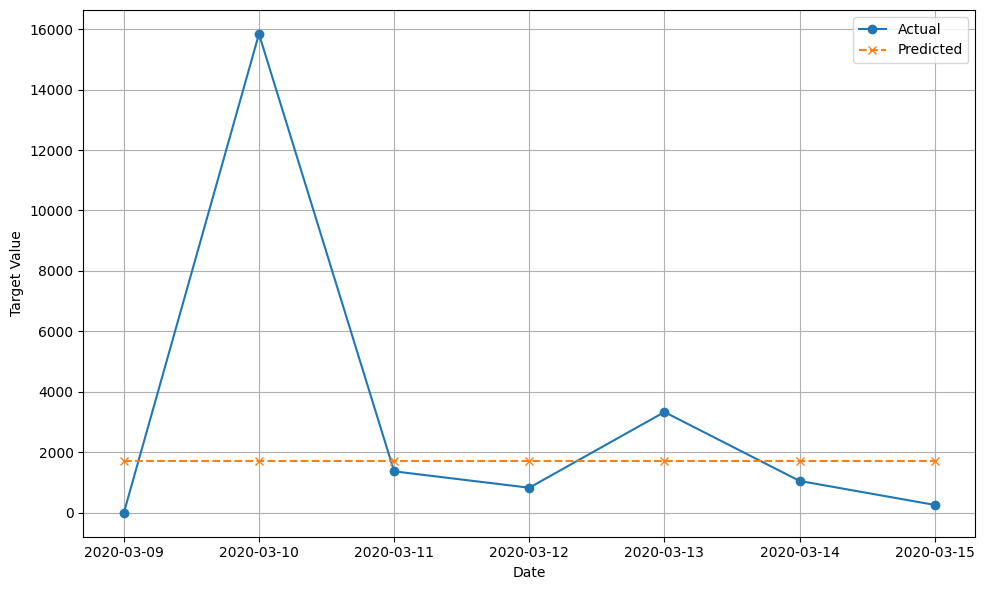


Fold 5 (797 train / 7 test)
MAE: 2969.335, RMSE: 5460.281, R2: -0.086

Average Metrics Across Folds:
MAE: 1865.601
RMSE: 2845.515
R2: -0.226
mae_ratio: 0.911
Temporal Cross-Validation Results:
Series([], dtype: float64)
0.0


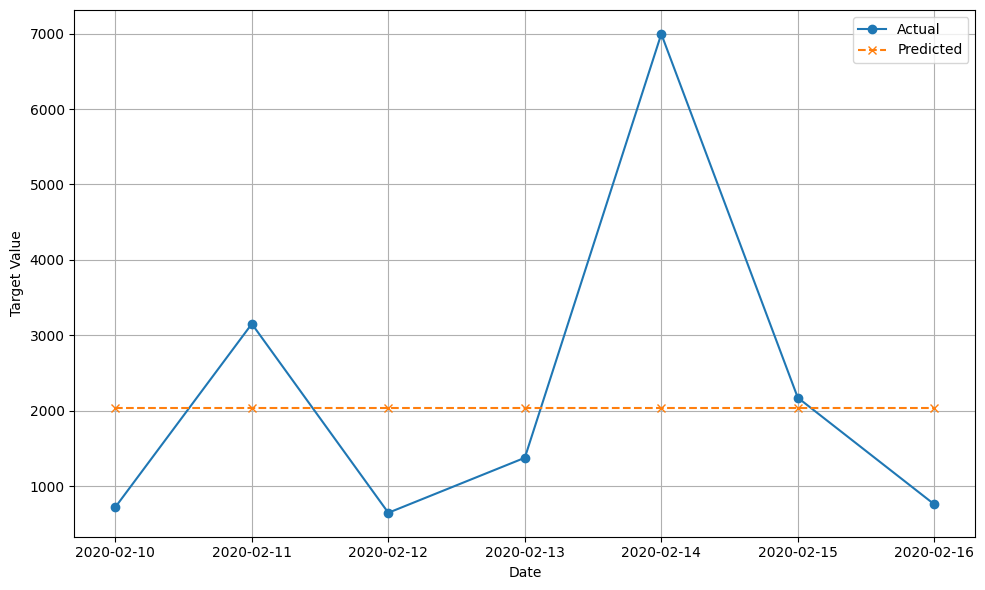


Fold 1 (745 train / 7 test)
MAE: 1550.097, RMSE: 2124.788, R2: -0.012
Series([], dtype: float64)
0.0


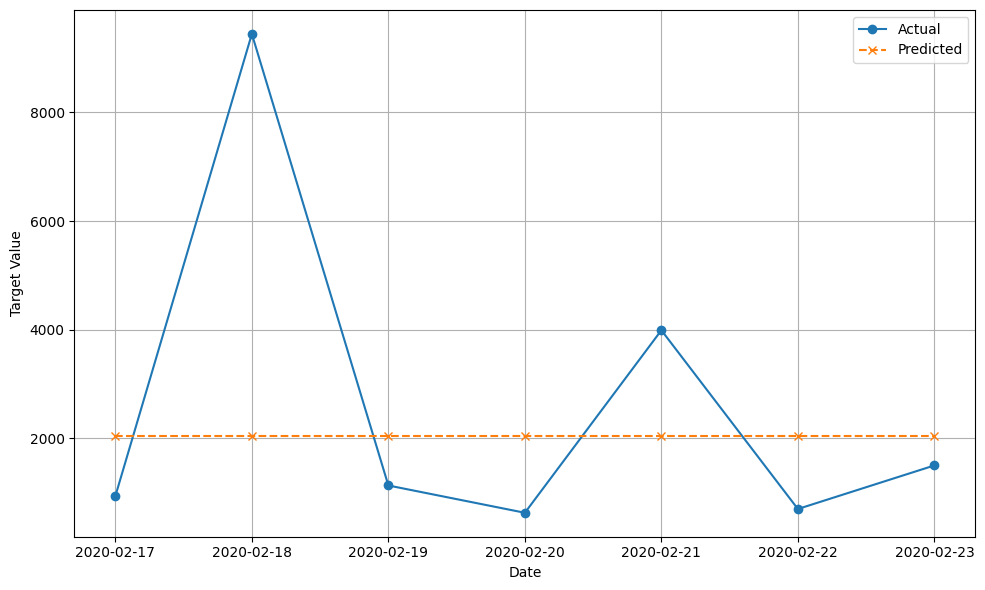


Fold 2 (752 train / 7 test)
MAE: 2092.155, RMSE: 3042.554, R2: -0.038
Series([], dtype: float64)
0.0


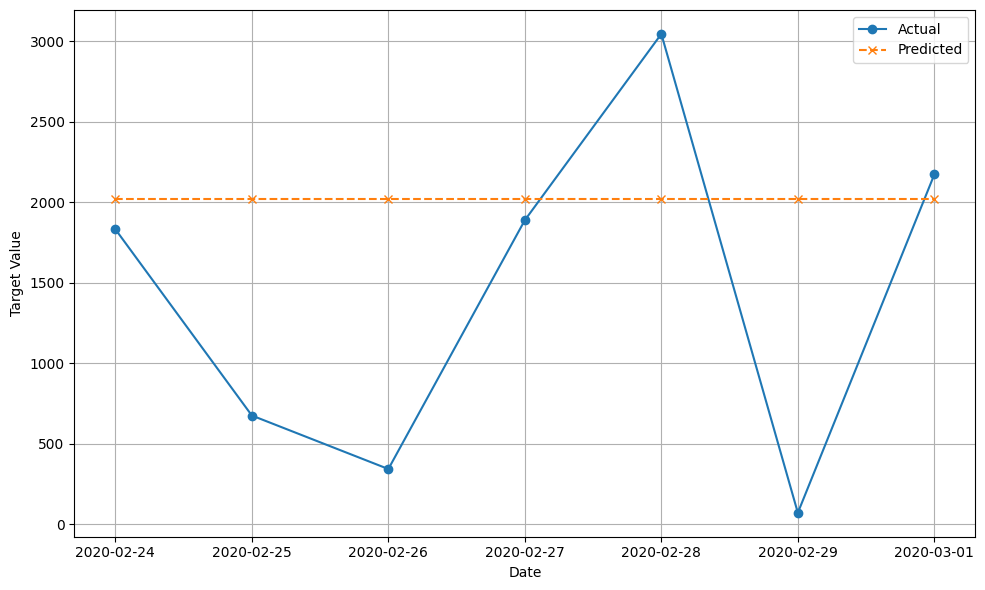


Fold 3 (759 train / 7 test)
MAE: 924.565, RMSE: 1168.511, R2: -0.341
Series([], dtype: float64)
0.0


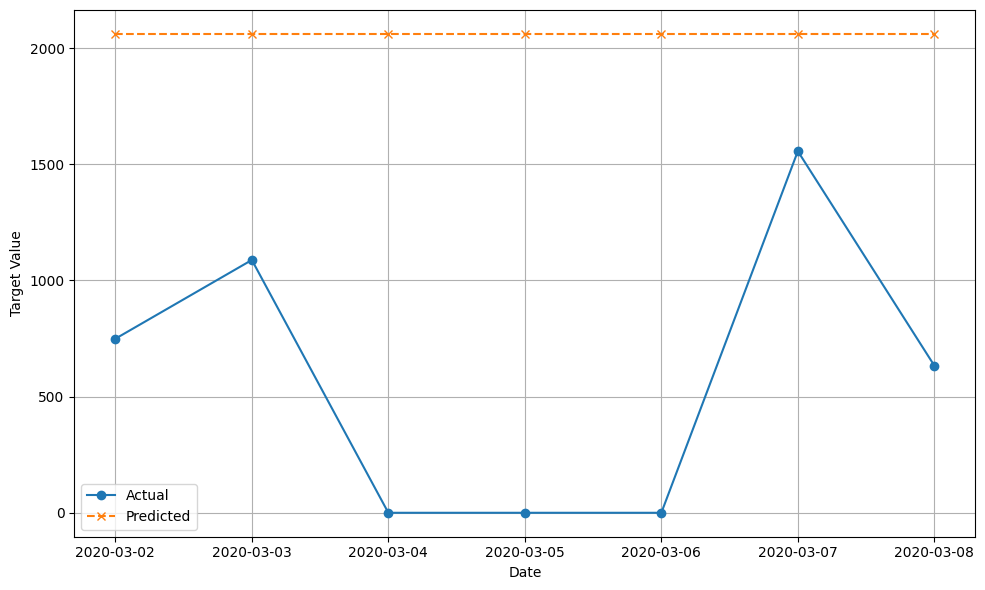


Fold 4 (766 train / 7 test)
MAE: 1485.617, RMSE: 1590.185, R2: -6.862
Series([], dtype: float64)
0.0


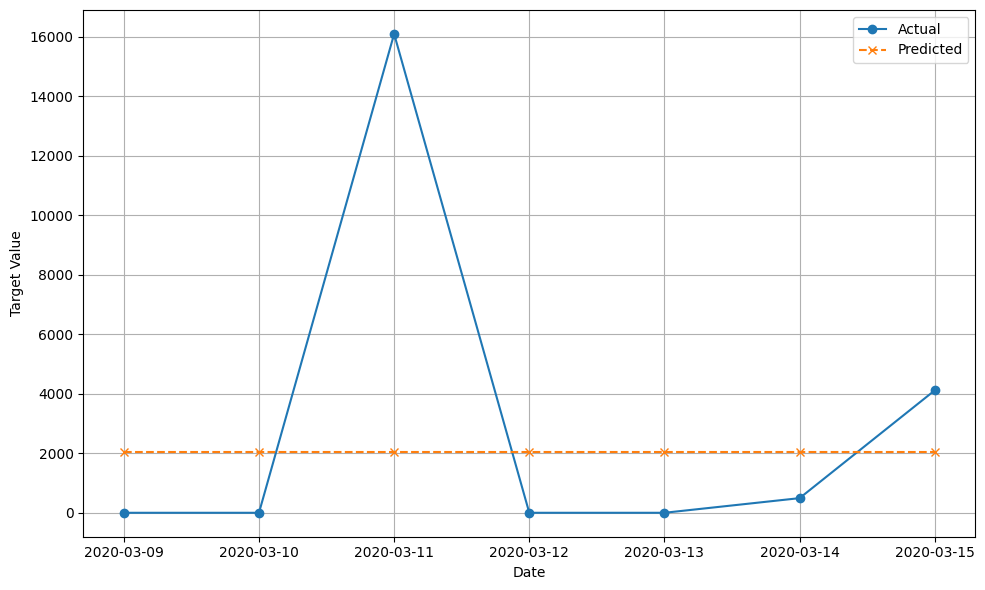


Fold 5 (773 train / 7 test)
MAE: 3698.090, RMSE: 5614.372, R2: -0.026

Average Metrics Across Folds:
MAE: 1950.105
RMSE: 2708.082
R2: -1.456
mae_ratio: 1.193


In [42]:
model = HistoricalMeanBaseline
params = {}
metrics = evaluate_model_on_clients(data, [2736675, 1926324, 207417], model, params)


In [43]:
metrics

{2736675: {'avg_MAE': 878.3350265706065,
  'avg_MSE': 3014705.762893124,
  'avg_RMSE': 1218.236005094635,
  'avg_R2': -0.9244405908008897,
  'avg_mae_ratio': 1.0700161013422533},
 1926324: {'avg_MAE': 1865.6014682391935,
  'avg_MSE': 10315533.948114658,
  'avg_RMSE': 2845.5145247325067,
  'avg_R2': -0.22593106911892727,
  'avg_mae_ratio': 0.9110751132043772},
 207417: {'avg_MAE': 1950.1045478881922,
  'avg_MSE': 9837427.568134945,
  'avg_RMSE': 2708.081868705379,
  'avg_R2': -1.4558334077875341,
  'avg_mae_ratio': 1.1926580092126575}}

In [35]:
mean_metrics = {
    'mean_MAE': np.mean([d['avg_MAE'] for k, d in metrics.items()]),
    'mean_MSE': np.mean([d['avg_MSE'] for k, d in metrics.items()]),
    'mean_RMSE': np.mean([d['avg_RMSE'] for k, d in metrics.items()]),
    'mean_R2': np.mean([d['avg_R2'] for k, d in metrics.items()]),
    'mean_mae_ratio': np.mean([d['avg_mae_ratio'] for k, d in metrics.items()])
}
mean_metrics

{'mean_MAE': 1545.9647506583735,
 'mean_MSE': 6921189.711809751,
 'mean_RMSE': 2004.6145636115625,
 'mean_R2': -3.303861345342595,
 'mean_mae_ratio': 0.9241982255571031}